In [ ]:
# ============================================
# Step 1: Imports
# ============================================

import os
import sys
import json
import zipfile
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Pandas version: 2.2.3
NumPy version: 2.1.3


In [ ]:
# ============================================
# Step 2: Mount Google Drive
# ============================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected!


In [ ]:
# ============================================
# Step 3: Project Directories
# ============================================

PROJECT_DIR = "/content/drive/MyDrive/Phishing_Email_AI"

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "xgboost_edgephish"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "xgboost_edgephish"
)

CONFIG_DIR = os.path.join(
    PROJECT_DIR,
    "config",
    "xgboost_edgephish"
)

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "edgephish"
)

for directory in [
    MODEL_DIR,
    RESULTS_DIR,
    CONFIG_DIR,
    DATA_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Project directories created!")

print("\nModels:", MODEL_DIR)
print("Results:", RESULTS_DIR)
print("Config:", CONFIG_DIR)
print("Data:", DATA_DIR)

Project directories created!

Models: /content/drive/MyDrive/Phishing_Email_AI/models/xgboost_edgephish
Results: /content/drive/MyDrive/Phishing_Email_AI/results/xgboost_edgephish
Config: /content/drive/MyDrive/Phishing_Email_AI/config/xgboost_edgephish
Data: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish


In [ ]:
# ============================================
# Step 4: Upload EdgePhish Dataset
# ============================================

from google.colab import files

uploaded = files.upload()

Saving edgephish_data_processed.zip to edgephish_data_processed.zip


In [ ]:
# ============================================
# Step 5: Save Dataset to Google Drive
# ============================================

import shutil
import os

source = "/content/edgephish_data_processed.zip"

destination = (
    "/content/drive/MyDrive/Phishing_Email_AI/data/edgephish"
)

shutil.copy2(source, destination)

print("Dataset copied to Google Drive!")
print()
print("Location:")
print(destination)

print()
print(
    "Size:",
    round(os.path.getsize(destination) / (1024 * 1024), 2),
    "MB"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/edgephish_data_processed.zip'

In [ ]:
# ============================================
# Step 5 FIX: Verify Dataset on Google Drive
# ============================================

import os

DATA_DIR = "/content/drive/MyDrive/Phishing_Email_AI/data/edgephish"

print("Files in EdgePhish Drive folder:")
print("=" * 50)

for file in os.listdir(DATA_DIR):
    file_path = os.path.join(DATA_DIR, file)

    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"{file}")
        print(f"Size: {size_mb:.2f} MB")
        print()

Files in EdgePhish Drive folder:
edgephish_data_processed.zip
Size: 344.98 MB

train_features.parquet
Size: 4.82 MB

validation_features.parquet
Size: 1.07 MB

test_features.parquet
Size: 0.98 MB



In [ ]:
# ============================================
# Step 6: Inspect EdgePhish ZIP Contents
# ============================================

import zipfile
import os

ZIP_PATH = os.path.join(
    DATA_DIR,
    "edgephish_data_processed.zip"
)

print("ZIP exists:", os.path.exists(ZIP_PATH))

if os.path.exists(ZIP_PATH):
    print(
        "ZIP size:",
        round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2),
        "MB"
    )

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        file_list = z.namelist()

    print("\nFiles inside EdgePhish-5G ZIP:")
    print("=" * 50)

    for file in file_list:
        print(file)

ZIP exists: True
ZIP size: 344.98 MB

Files inside EdgePhish-5G ZIP:
zenodo/
zenodo/DATASET_README.md
zenodo/edgephish_data_processed/
zenodo/edgephish_data_processed/adversarial/
zenodo/edgephish_data_processed/adversarial/adversarial_manifest.json
zenodo/edgephish_data_processed/adversarial/perturbed/
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r01.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r05.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r10.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r20.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r01.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r05.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r10.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r20.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/p

In [ ]:
# ============================================
# Step 7: Extract Required EdgePhish Data
# ============================================

import zipfile
import os

ZIP_PATH = os.path.join(
    DATA_DIR,
    "edgephish_data_processed.zip"
)

EXTRACT_DIR = os.path.join(
    DATA_DIR,
    "extracted"
)

os.makedirs(EXTRACT_DIR, exist_ok=True)

required_files = [
    "zenodo/edgephish_data_processed/splits/primary_authoritative/train.parquet",
    "zenodo/edgephish_data_processed/splits/primary_authoritative/val.parquet",
    "zenodo/edgephish_data_processed/splits/primary_authoritative/test.parquet",
    "zenodo/edgephish_data_processed/splits/primary_authoritative/zero_day.parquet",
]

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    for file in required_files:

        print("Extracting:", file)

        z.extract(
            file,
            EXTRACT_DIR
        )

print("\nExtraction completed!")

Extracting: zenodo/edgephish_data_processed/splits/primary_authoritative/train.parquet
Extracting: zenodo/edgephish_data_processed/splits/primary_authoritative/val.parquet
Extracting: zenodo/edgephish_data_processed/splits/primary_authoritative/test.parquet
Extracting: zenodo/edgephish_data_processed/splits/primary_authoritative/zero_day.parquet

Extraction completed!


In [ ]:
# ============================================
# Step 8: Define Dataset Paths
# ============================================

BASE_EXTRACT = os.path.join(
    EXTRACT_DIR,
    "zenodo",
    "edgephish_data_processed",
    "splits",
    "primary_authoritative"
)

TRAIN_PATH = os.path.join(
    BASE_EXTRACT,
    "train.parquet"
)

VAL_PATH = os.path.join(
    BASE_EXTRACT,
    "val.parquet"
)

TEST_PATH = os.path.join(
    BASE_EXTRACT,
    "test.parquet"
)

ZERO_DAY_PATH = os.path.join(
    BASE_EXTRACT,
    "zero_day.parquet"
)

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)
print("Zero-day:", ZERO_DAY_PATH)

Train: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/extracted/zenodo/edgephish_data_processed/splits/primary_authoritative/train.parquet
Validation: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/extracted/zenodo/edgephish_data_processed/splits/primary_authoritative/val.parquet
Test: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/extracted/zenodo/edgephish_data_processed/splits/primary_authoritative/test.parquet
Zero-day: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/extracted/zenodo/edgephish_data_processed/splits/primary_authoritative/zero_day.parquet


In [ ]:
# ============================================
# Fix: Load Required Libraries
# ============================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

print("Libraries loaded successfully!")
print("Pandas:", pd.__version__)

Libraries loaded successfully!
Pandas: 2.2.3


In [ ]:
# ============================================
# Step 9: Load EdgePhish Datasets
# ============================================

print("Loading training data...")
train_df = pd.read_parquet(TRAIN_PATH)

print("Loading validation data...")
val_df = pd.read_parquet(VAL_PATH)

print("Loading test data...")
test_df = pd.read_parquet(TEST_PATH)

print("Loading zero-day data...")
zero_day_df = pd.read_parquet(ZERO_DAY_PATH)

print("\nLoaded successfully!")

Loading training data...
Loading validation data...
Loading test data...
Loading zero-day data...

Loaded successfully!


In [ ]:
# ============================================
# Step 10: Dataset Sizes
# ============================================

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Zero-Day:", zero_day_df.shape)

print("\nTotal rows:")
print(
    len(train_df)
    + len(val_df)
    + len(test_df)
    + len(zero_day_df)
)

Training: (238000, 8)
Validation: (51000, 8)
Test: (46000, 8)
Zero-Day: (4525, 8)

Total rows:
339525


In [ ]:
# ============================================
# Step 11: Inspect Dataset Columns
# ============================================

print("Training columns:")
print("=" * 60)

for i, col in enumerate(train_df.columns):
    print(f"{i:2}. {col}")

print("\nNumber of columns:", len(train_df.columns))

Training columns:
 0. url
 1. url_orig
 2. label
 3. slice
 4. URLLC_score
 5. mMTC_score
 6. url_raw_len
 7. _orig_idx

Number of columns: 8


In [ ]:
print("\nData types:")
print(train_df.dtypes)


Data types:
url            object
url_orig       object
label           int64
slice          object
URLLC_score     int64
mMTC_score      int64
url_raw_len     int64
_orig_idx       int64
dtype: object


In [ ]:
# ============================================
# Step 12: First 5 Rows
# ============================================

display(train_df.head())

,url,url_orig,label,slice,URLLC_score,mMTC_score,url_raw_len,_orig_idx
0,https://www.nyls.edu/news-and-events/calendar/...,https://www.nyls.edu/news-and-events/calendar/...,0,eMBB,0,0,66,0
1,https://www.marburg.de/politik-stadtgesellscha...,https://www.marburg.de/politik-stadtgesellscha...,0,eMBB,0,0,122,1
2,https://www.gtcbio.com/newdemo/modules/l.php,https://www.gtcbio.com/newdemo/modules/l.php,1,eMBB,0,0,44,2
3,http://mc948.comoj.com/index.html.html,http://mc948.comoj.com/index.html.html,1,eMBB,0,0,38,3
4,https://www.afponline.org/trends-topics/topics...,https://www.afponline.org/trends-topics/topics...,0,eMBB,2,0,118,4


In [ ]:
# ============================================
# Step 12B: Random Samples
# ============================================

display(
    train_df.sample(
        10,
        random_state=42
    )
)

,url,url_orig,label,slice,URLLC_score,mMTC_score,url_raw_len,_orig_idx
36270,https://www.iaslc.org/articles/active-surveill...,https://www.iaslc.org/articles/active-surveill...,0,eMBB,0,0,118,36292
1116,http://business-eb.client522673268-form.bbt.co...,http://business-eb.client522673268-form.bbt.co...,1,eMBB,0,0,82,1116
30677,http://thinkorange.com/reggieleadership_1920x450/,http://thinkorange.com/reggieleadership_1920x450/,0,eMBB,0,0,49,30692
138229,https://www.dra.ru/domeny,https://www.dra.ru/domeny,0,eMBB,0,0,25,138351
3731,http://session-4195817.nationalcity.com.proter...,http://session-4195817.nationalcity.com.proter...,1,eMBB,0,0,90,3731
143251,http://signin.ebay.com.ws.ebayisapi.dll.signin...,http://signin.ebay.com.ws.ebayisapi.dll.signin...,1,eMBB,0,1,454,143381
8387,http://www.hds.com/ppc/ebook-portfolio/,http://www.hds.com/ppc/ebook-portfolio/,0,eMBB,0,0,39,8389
5845,https://foresight.org/stage2/index.html,https://foresight.org/stage2/index.html,0,eMBB,0,0,39,5847
20455,http://www.emotionprinting.com/KieraHatton/mod...,http://www.emotionprinting.com/KieraHatton/mod...,1,eMBB,0,0,94,20464
158871,https://www.macworld.com/article/2936192/faceb...,https://www.macworld.com/article/2936192/faceb...,0,eMBB,0,0,104,159032


In [ ]:
# ============================================
# Step 13: Identify Label Columns
# ============================================

print("Potential label columns:")

for col in train_df.columns:
    if any(
        word in col.lower()
        for word in [
            "label",
            "target",
            "class",
            "phish"
        ]
    ):
        print(col)

Potential label columns:
label


In [ ]:
# ============================================
# Step 14: Missing Values
# ============================================

missing = train_df.isnull().sum()

print("Columns with missing values:")

display(
    missing[
        missing > 0
    ].sort_values(
        ascending=False
    )
)

Columns with missing values:


,0


In [ ]:
print(
    "\nTotal missing values:",
    train_df.isnull().sum().sum()
)


Total missing values: 0


In [ ]:
# ============================================
# Step 15: Duplicate URLs
# ============================================

print(
    "Duplicate rows:",
    train_df.duplicated().sum()
)

if "url" in train_df.columns:

    print(
        "Duplicate normalized URLs:",
        train_df["url"].duplicated().sum()
    )

if "url_orig" in train_df.columns:

    print(
        "Duplicate original URLs:",
        train_df["url_orig"].duplicated().sum()
    )

Duplicate rows: 0
Duplicate normalized URLs: 0
Duplicate original URLs: 0


In [ ]:
# ============================================
# Step 13: Label Distribution
# ============================================

print("Training label distribution:")
print(train_df["label"].value_counts())

print("\nTraining label percentages:")
print(
    (train_df["label"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

print("\nZero-Day label distribution:")
print(zero_day_df["label"].value_counts())

Training label distribution:
label
0    119150
1    118850
Name: count, dtype: int64

Training label percentages:
label
0    50.06
1    49.94
Name: proportion, dtype: float64

Validation label distribution:
label
0    25622
1    25378
Name: count, dtype: int64

Test label distribution:
label
1    23040
0    22960
Name: count, dtype: int64

Zero-Day label distribution:
label
0    2264
1    2261
Name: count, dtype: int64


In [ ]:
# ============================================
# Step 14: Dataset Metadata Audit
# ============================================

print("Slice values:")
print(train_df["slice"].value_counts())

print("\nURLLC score:")
print(train_df["URLLC_score"].value_counts().sort_index())

print("\nmMTC score:")
print(train_df["mMTC_score"].value_counts().sort_index())

print("\n_orig_idx range:")
print(
    train_df["_orig_idx"].min(),
    "to",
    train_df["_orig_idx"].max()
)

Slice values:
slice
eMBB     217914
mMTC      14856
URLLC      5230
Name: count, dtype: int64

URLLC score:
URLLC_score
0    227284
1      1163
2      4323
3      5160
4        45
5        25
Name: count, dtype: int64

mMTC score:
mMTC_score
0    194542
1     28166
2     13706
3      1536
4        39
5        11
Name: count, dtype: int64

_orig_idx range:
0 to 238296


In [ ]:
# ============================================
# Step 15: Cross-Split URL Leakage Audit
# ============================================

train_urls = set(train_df["url"])
val_urls = set(val_df["url"])
test_urls = set(test_df["url"])
zero_urls = set(zero_day_df["url"])

print("Train ∩ Validation:", len(train_urls & val_urls))
print("Train ∩ Test:", len(train_urls & test_urls))
print("Train ∩ Zero-Day:", len(train_urls & zero_urls))

print("Validation ∩ Test:", len(val_urls & test_urls))
print("Validation ∩ Zero-Day:", len(val_urls & zero_urls))
print("Test ∩ Zero-Day:", len(test_urls & zero_urls))

Train ∩ Validation: 0
Train ∩ Test: 0
Train ∩ Zero-Day: 0
Validation ∩ Test: 0
Validation ∩ Zero-Day: 0
Test ∩ Zero-Day: 0


In [ ]:
# ============================================
# Step 16: URL Normalization Audit
# ============================================

same_url = (
    train_df["url"].astype(str)
    ==
    train_df["url_orig"].astype(str)
)

print(
    "url == url_orig:",
    same_url.mean() * 100,
    "%"
)

print("\nExamples where they differ:")

display(
    train_df.loc[
        ~same_url,
        ["url", "url_orig"]
    ].head(10)
)

url == url_orig: 99.60084033613445 %

Examples where they differ:


,url,url_orig
410,http://commercialandbusiness.bankofamerica.usa...,http://commercialandbusiness.bankofamerica.usa...
453,http://wc.wachovia.ibsidcmopserver.cmserver.ac...,http://wc.wachovia.ibsIDcmopserver.cmserver.ac...
587,http://orioninsaat.com.tr/~zeedee/9a70c0acdb25...,http://orioninsaat.com.tr/~zeedee/9a70c0acdb25...
753,http://69.64.33.148/wind/acquisti@agenziagemin...,http://69.64.33.148/wind/acquisti@agenziagemin...
838,http://211-72-2-202.hinet-ip.hinet.net/co.php,http://211-72-2-202.HINET-IP.hinet.net/co.php
1128,https://lblockchains.info/wallet/,https://lblockchains.info/wallet/#/login
1145,http://www.paypal.com.0.sessionid.rxi2tukj0eqr...,http://www.paypal.com.0.sessionid.rxi2Tukj0EQr...
1200,http://dicafree.com//zboard/icon/www.paypal.co...,http://dicafree.com//zboard/icon/www.paypal.co...
1258,http://enterprise2.openbank.actionvalidate.hyc...,http://enterprise2.openbank.actionvalidate.Hyc...
1328,http://direct.bankofamerica.usanationwide.exac...,http://direct.bankofamerica.usanationwide.exac...


In [ ]:
# ============================================
# Step 17: URL Length Audit
# ============================================

print("Normalized URL length:")
display(
    train_df["url"]
    .astype(str)
    .str.len()
    .describe()
)

print("\nOriginal URL length:")
display(
    train_df["url_orig"]
    .astype(str)
    .str.len()
    .describe()
)

Normalized URL length:


,url
count,238000.000000
mean,79.050004
std,52.153185
min,11.000000
25%,47.000000
50%,65.000000
75%,93.000000
max,512.000000



Original URL length:


,url_orig
count,238000.000000
mean,79.125765
std,52.273397
min,4.000000
25%,47.000000
50%,65.000000
75%,93.000000
max,512.000000


In [ ]:
# ============================================
# Step 18A: Additional Imports
# ============================================

import time
import re
from urllib.parse import urlparse, unquote

print("Imports ready!")

Imports ready!


In [ ]:
# ============================================
# Step 18B: Suspicious Keyword Configuration
# ============================================

SUSPICIOUS_KEYWORDS = [
    "login",
    "signin",
    "sign-in",
    "verify",
    "verification",
    "account",
    "update",
    "secure",
    "security",
    "confirm",
    "confirmation",
    "password",
    "credential",
    "authenticate",
    "authentication",
    "banking",
    "bank",
    "payment",
    "billing",
    "invoice",
    "wallet",
    "recover",
    "unlock",
    "suspend",
    "alert",
    "urgent",
    "limited",
    "bonus",
    "gift",
    "claim",
    "free"
]

# Brand names are NOT suspicious by themselves.
# They are tracked separately as potential impersonation indicators.

BRAND_KEYWORDS = [
    "paypal",
    "amazon",
    "microsoft",
    "apple",
    "google",
    "facebook",
    "instagram",
    "outlook"
]

print("Suspicious keywords:", len(SUSPICIOUS_KEYWORDS))
print("Brand keywords:", len(BRAND_KEYWORDS))

Suspicious keywords: 31
Brand keywords: 8


In [ ]:
# ============================================
# Step 18C: Corrected URL Feature Extractor
# ============================================

IPV4_PATTERN = re.compile(
    r"^(?:\d{1,3}\.){3}\d{1,3}$"
)


def extract_url_features(url):
    """
    Extract URL-only features that can be reproduced
    during real email analysis.
    """

    if pd.isna(url):
        url = ""

    url = str(url).strip()

    original_url = url

    # ----------------------------------------
    # Ensure URL has a scheme for parsing
    # ----------------------------------------

    if not re.match(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        url
    ):
        parse_url = "http://" + url
    else:
        parse_url = url

    parsed = urlparse(parse_url)

    normalized = url.lower()

    decoded_url = unquote(normalized)

    domain = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""
    fragment = parsed.fragment or ""

    # ----------------------------------------
    # Basic lengths
    # ----------------------------------------

    url_length = len(original_url)

    domain_length = len(domain)

    path_length = len(path)

    query_length = len(query)

    fragment_length = len(fragment)

    # ----------------------------------------
    # Character counts
    # ----------------------------------------

    num_digits = sum(
        c.isdigit()
        for c in original_url
    )

    num_letters = sum(
        c.isalpha()
        for c in original_url
    )

    num_dots = original_url.count(".")

    num_hyphens = original_url.count("-")

    num_slashes = original_url.count("/")

    num_question_marks = original_url.count("?")

    num_equals = original_url.count("=")

    num_ampersands = original_url.count("&")

    num_at_symbols = original_url.count("@")

    num_colons = original_url.count(":")

    num_underscores = original_url.count("_")

    num_percent_encoded = len(
        re.findall(
            r"%[0-9a-fA-F]{2}",
            original_url
        )
    )

    num_semicolons = original_url.count(";")

    num_special_chars = sum(
        not c.isalnum()
        for c in original_url
    )

    # ----------------------------------------
    # Ratios
    # ----------------------------------------

    digit_ratio = (
        num_digits / url_length
        if url_length > 0
        else 0
    )

    letter_ratio = (
        num_letters / url_length
        if url_length > 0
        else 0
    )

    special_char_ratio = (
        num_special_chars / url_length
        if url_length > 0
        else 0
    )

    # ----------------------------------------
    # IP address detection
    # ----------------------------------------

    is_domain_ip = int(
        bool(IPV4_PATTERN.match(domain))
    )

    # ----------------------------------------
    # Domain characteristics
    # ----------------------------------------

    domain_digit_count = sum(
        c.isdigit()
        for c in domain
    )

    domain_hyphen_count = domain.count("-")

    domain_dot_count = domain.count(".")

    # Don't count IP components as subdomains
    if is_domain_ip:
        num_subdomains = 0
    elif domain:
        domain_parts = domain.split(".")
        num_subdomains = max(
            len(domain_parts) - 2,
            0
        )
    else:
        num_subdomains = 0

    has_www = int(
        domain.startswith("www.")
    )

    # ----------------------------------------
    # Protocol
    # ----------------------------------------

    is_https = int(
        parsed.scheme.lower() == "https"
    )

    # ----------------------------------------
    # Obfuscation
    # ----------------------------------------

    has_obfuscation = int(
        num_percent_encoded > 0
        or num_at_symbols > 0
    )

    # ----------------------------------------
    # Path characteristics
    # ----------------------------------------

    path_slashes = path.count("/")

    path_segments = [
        segment
        for segment in path.split("/")
        if segment
    ]

    num_path_segments = len(
        path_segments
    )

    # ----------------------------------------
    # Suspicious keywords
    # ----------------------------------------

    suspicious_keyword_matches = [
        keyword
        for keyword in SUSPICIOUS_KEYWORDS
        if keyword in decoded_url
    ]

    suspicious_keyword_count = len(
        suspicious_keyword_matches
    )

    has_suspicious_keyword = int(
        suspicious_keyword_count > 0
    )

    # ----------------------------------------
    # Brand indicators
    # ----------------------------------------

    brand_matches = [
        brand
        for brand in BRAND_KEYWORDS
        if brand in decoded_url
    ]

    brand_keyword_count = len(
        brand_matches
    )

    has_brand_keyword = int(
        brand_keyword_count > 0
    )

    # Brand appears outside the domain
    # (potential impersonation signal)
    brand_in_path_or_query = int(
        any(
            brand in (path + "?" + query)
            for brand in BRAND_KEYWORDS
        )
    )

    # ----------------------------------------
    # Query characteristics
    # ----------------------------------------

    query_parameter_count = (
        query.count("&") + 1
        if query
        else 0
    )

    # ----------------------------------------
    # Return feature dictionary
    # ----------------------------------------

    return {

        # URL structure
        "URLLength": url_length,
        "DomainLength": domain_length,
        "PathLength": path_length,
        "QueryLength": query_length,
        "FragmentLength": fragment_length,

        # Character patterns
        "NumDigits": num_digits,
        "NumLetters": num_letters,
        "NumDots": num_dots,
        "NumHyphens": num_hyphens,
        "NumSlashes": num_slashes,
        "NumQuestionMarks": num_question_marks,
        "NumEquals": num_equals,
        "NumAmpersands": num_ampersands,
        "NumAtSymbols": num_at_symbols,
        "NumColons": num_colons,
        "NumUnderscores": num_underscores,
        "NumPercentEncoded": num_percent_encoded,
        "NumSemicolons": num_semicolons,
        "NumSpecialChars": num_special_chars,

        # Ratios
        "DigitRatio": digit_ratio,
        "LetterRatio": letter_ratio,
        "SpecialCharRatio": special_char_ratio,

        # Domain
        "DomainDigitCount": domain_digit_count,
        "DomainHyphenCount": domain_hyphen_count,
        "DomainDotCount": domain_dot_count,
        "IsDomainIP": is_domain_ip,
        "NumSubdomains": num_subdomains,
        "HasWWW": has_www,

        # Protocol
        "IsHTTPS": is_https,

        # Obfuscation
        "EncodedCharCount": num_percent_encoded,
        "HasObfuscation": has_obfuscation,

        # Path
        "PathSlashes": path_slashes,
        "NumPathSegments": num_path_segments,

        # Suspicious language
        "SuspiciousKeywordCount": suspicious_keyword_count,
        "HasSuspiciousKeyword": has_suspicious_keyword,

        # Brand indicators
        "BrandKeywordCount": brand_keyword_count,
        "HasBrandKeyword": has_brand_keyword,
        "BrandInPathOrQuery": brand_in_path_or_query,

        # Query
        "QueryParameterCount": query_parameter_count
    }

In [ ]:
# ============================================
# Step 18D: Re-test Feature Extractor
# ============================================

test_urls = [
    "https://www.google.com",

    "https://www.amazon.com/account/login",

    "http://paypal-security-verify.com/login?account=12345",

    "http://192.168.1.100/login/verify.php?user=test",

    "https://example.com/products/item?id=123"
]

for url in test_urls:

    print("\n" + "=" * 70)
    print("URL:")
    print(url)

    features = extract_url_features(url)

    print("\nSelected features:")

    for key in [
        "URLLength",
        "DomainLength",
        "NumDots",
        "NumHyphens",
        "NumSlashes",
        "NumDigits",
        "IsDomainIP",
        "NumSubdomains",
        "IsHTTPS",
        "NumPathSegments",
        "SuspiciousKeywordCount",
        "HasSuspiciousKeyword",
        "BrandKeywordCount",
        "HasBrandKeyword",
        "BrandInPathOrQuery"
    ]:
        print(
            f"{key}: {features[key]}"
        )


URL:
https://www.google.com

Selected features:
URLLength: 22
DomainLength: 14
NumDots: 2
NumHyphens: 0
NumSlashes: 2
NumDigits: 0
IsDomainIP: 0
NumSubdomains: 1
IsHTTPS: 1
NumPathSegments: 0
SuspiciousKeywordCount: 0
HasSuspiciousKeyword: 0
BrandKeywordCount: 1
HasBrandKeyword: 1
BrandInPathOrQuery: 0

URL:
https://www.amazon.com/account/login

Selected features:
URLLength: 36
DomainLength: 14
NumDots: 2
NumHyphens: 0
NumSlashes: 4
NumDigits: 0
IsDomainIP: 0
NumSubdomains: 1
IsHTTPS: 1
NumPathSegments: 2
SuspiciousKeywordCount: 2
HasSuspiciousKeyword: 1
BrandKeywordCount: 1
HasBrandKeyword: 1
BrandInPathOrQuery: 0

URL:
http://paypal-security-verify.com/login?account=12345

Selected features:
URLLength: 53
DomainLength: 26
NumDots: 1
NumHyphens: 2
NumSlashes: 3
NumDigits: 5
IsDomainIP: 0
NumSubdomains: 0
IsHTTPS: 0
NumPathSegments: 1
SuspiciousKeywordCount: 4
HasSuspiciousKeyword: 1
BrandKeywordCount: 1
HasBrandKeyword: 1
BrandInPathOrQuery: 0

URL:
http://192.168.1.100/login/verify.

In [ ]:
# ============================================
# Step 19A: Feature Engineering - Training
# ============================================

start_time = time.time()

train_features = pd.DataFrame(
    [
        extract_url_features(url)
        for url in train_df["url_orig"]
    ]
)

train_features["label"] = train_df["label"].values

elapsed = time.time() - start_time

print("Training feature engineering completed!")
print("Shape:", train_features.shape)
print("Time:", round(elapsed, 2), "seconds")

display(train_features.head())

Training feature engineering completed!
Shape: (238000, 40)
Time: 21.69 seconds


,URLLength,DomainLength,PathLength,QueryLength,FragmentLength,NumDigits,NumLetters,NumDots,NumHyphens,NumSlashes,...,HasObfuscation,PathSlashes,NumPathSegments,SuspiciousKeywordCount,HasSuspiciousKeyword,BrandKeywordCount,HasBrandKeyword,BrandInPathOrQuery,QueryParameterCount,label
0,66,12,46,0,0,1,51,2,5,6,...,0,4,3,0,0,0,0,0,0,0
1,122,14,100,0,0,0,109,2,2,8,...,0,6,5,0,0,0,0,0,0,0
2,44,14,22,0,0,0,35,3,0,5,...,0,3,3,0,0,0,0,0,0,1
3,38,15,16,0,0,3,27,4,0,3,...,0,1,1,0,0,0,0,0,0,1
4,118,17,93,0,0,0,99,2,9,7,...,0,5,5,0,0,0,0,0,0,0


In [ ]:
# ============================================
# Step 19B: Feature Engineering - Validation
# ============================================

start_time = time.time()

val_features = pd.DataFrame(
    [
        extract_url_features(url)
        for url in val_df["url_orig"]
    ]
)

val_features["label"] = val_df["label"].values

print(
    "Validation feature engineering completed!"
)

print("Shape:", val_features.shape)
print("Time:", round(time.time() - start_time, 2), "seconds")

Validation feature engineering completed!
Shape: (51000, 40)
Time: 3.41 seconds


In [ ]:
# ============================================
# Step 19C: Feature Engineering - Test
# ============================================

start_time = time.time()

test_features = pd.DataFrame(
    [
        extract_url_features(url)
        for url in test_df["url_orig"]
    ]
)

test_features["label"] = test_df["label"].values

print(
    "Test feature engineering completed!"
)

print("Shape:", test_features.shape)
print("Time:", round(time.time() - start_time, 2), "seconds")

Test feature engineering completed!
Shape: (46000, 40)
Time: 4.96 seconds


In [ ]:
# ============================================
# Step 20: Engineered Dataset Audit
# ============================================

print("Training:", train_features.shape)
print("Validation:", val_features.shape)
print("Test:", test_features.shape)

print("\nMissing values:")
print(
    "Train:",
    train_features.isnull().sum().sum()
)

print(
    "Validation:",
    val_features.isnull().sum().sum()
)

print(
    "Test:",
    test_features.isnull().sum().sum()
)

print("\nInfinite values:")

print(
    "Train:",
    np.isinf(
        train_features.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "Validation:",
    np.isinf(
        val_features.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "Test:",
    np.isinf(
        test_features.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

Training: (238000, 40)
Validation: (51000, 40)
Test: (46000, 40)

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0


In [ ]:
# ============================================
# Step 21: Feature List
# ============================================

FEATURE_COLUMNS = [
    col
    for col in train_features.columns
    if col != "label"
]

print("Number of features:", len(FEATURE_COLUMNS))

print("\nFeatures:")
for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i:2}. {feature}")

Number of features: 39

Features:
 1. URLLength
 2. DomainLength
 3. PathLength
 4. QueryLength
 5. FragmentLength
 6. NumDigits
 7. NumLetters
 8. NumDots
 9. NumHyphens
10. NumSlashes
11. NumQuestionMarks
12. NumEquals
13. NumAmpersands
14. NumAtSymbols
15. NumColons
16. NumUnderscores
17. NumPercentEncoded
18. NumSemicolons
19. NumSpecialChars
20. DigitRatio
21. LetterRatio
22. SpecialCharRatio
23. DomainDigitCount
24. DomainHyphenCount
25. DomainDotCount
26. IsDomainIP
27. NumSubdomains
28. HasWWW
29. IsHTTPS
30. EncodedCharCount
31. HasObfuscation
32. PathSlashes
33. NumPathSegments
34. SuspiciousKeywordCount
35. HasSuspiciousKeyword
36. BrandKeywordCount
37. HasBrandKeyword
38. BrandInPathOrQuery
39. QueryParameterCount


In [ ]:
# ============================================
# Step 22: Feature Statistics
# ============================================

feature_stats = train_features[
    FEATURE_COLUMNS
].describe().T

display(
    feature_stats[
        ["min", "max", "mean", "std"]
    ].round(4)
)

,min,max,mean,std
URLLength,4.0000,512.0000,79.1258,52.2734
DomainLength,4.0000,251.0000,21.4764,18.2416
PathLength,0.0000,499.0000,38.0044,32.1297
QueryLength,0.0000,495.0000,11.9874,37.0823
FragmentLength,0.0000,358.0000,0.0739,2.7866
NumDigits,0.0000,397.0000,9.3715,18.0738
NumLetters,2.0000,504.0000,57.0137,35.0911
NumDots,0.0000,43.0000,2.9796,2.2015
NumHyphens,0.0000,91.0000,1.7750,2.9460
NumSlashes,0.0000,59.0000,5.2500,1.9832


In [ ]:
# ============================================
# Step 23: Constant Feature Check
# ============================================

constant_features = [
    col
    for col in FEATURE_COLUMNS
    if train_features[col].nunique() <= 1
]

print(
    "Constant features:",
    len(constant_features)
)

if constant_features:
    print("\nConstant features:")
    for feature in constant_features:
        print("-", feature)
else:
    print("No constant features found.")

Constant features: 0
No constant features found.


In [ ]:
# ============================================
# Step 24: Save Engineered Features
# ============================================

TRAIN_FEATURE_PATH = os.path.join(
    DATA_DIR,
    "train_features.parquet"
)

VAL_FEATURE_PATH = os.path.join(
    DATA_DIR,
    "validation_features.parquet"
)

TEST_FEATURE_PATH = os.path.join(
    DATA_DIR,
    "test_features.parquet"
)

train_features.to_parquet(
    TRAIN_FEATURE_PATH,
    index=False
)

val_features.to_parquet(
    VAL_FEATURE_PATH,
    index=False
)

test_features.to_parquet(
    TEST_FEATURE_PATH,
    index=False
)

print("Engineered datasets saved!")

print("\nTrain:", TRAIN_FEATURE_PATH)
print("Validation:", VAL_FEATURE_PATH)
print("Test:", TEST_FEATURE_PATH)

Engineered datasets saved!

Train: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/train_features.parquet
Validation: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/validation_features.parquet
Test: /content/drive/MyDrive/Phishing_Email_AI/data/edgephish/test_features.parquet


In [ ]:
# ============================================
# Step 23: Constant Feature Check
# ============================================

constant_features = [
    col
    for col in FEATURE_COLUMNS
    if train_features[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

if constant_features:
    print("\nConstant features:")
    for feature in constant_features:
        print("-", feature)
else:
    print("✓ No constant features found.")

Number of constant features: 0
✓ No constant features found.


In [ ]:
# ============================================
# Step 24: Feature Correlation Audit
# ============================================

correlation_matrix = train_features[
    FEATURE_COLUMNS
].corr()

high_correlations = []

for i in range(len(FEATURE_COLUMNS)):
    for j in range(i + 1, len(FEATURE_COLUMNS)):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.95:
            high_correlations.append(
                (
                    FEATURE_COLUMNS[i],
                    FEATURE_COLUMNS[j],
                    correlation
                )
            )

print(
    "Feature pairs with |correlation| >= 0.95:",
    len(high_correlations)
)

for feature_a, feature_b, correlation in high_correlations:
    print(
        f"{feature_a} <-> {feature_b}: "
        f"{correlation:.4f}"
    )

Feature pairs with |correlation| >= 0.95: 4
NumPercentEncoded <-> EncodedCharCount: 1.0000
DomainDotCount <-> NumSubdomains: 0.9851
PathSlashes <-> NumPathSegments: 0.9667
BrandKeywordCount <-> HasBrandKeyword: 0.9962


In [ ]:
# ============================================
# Step 25: Feature vs Label Analysis
# ============================================

feature_comparison = train_features.copy()

comparison = (
    feature_comparison
    .groupby("label")[FEATURE_COLUMNS]
    .mean()
    .T
)

comparison.columns = [
    "Legitimate (0)",
    "Phishing (1)"
]

comparison["Difference"] = (
    comparison["Phishing (1)"]
    - comparison["Legitimate (0)"]
)

comparison["Absolute Difference"] = (
    comparison["Difference"]
    .abs()
)

comparison = comparison.sort_values(
    "Absolute Difference",
    ascending=False
)

display(
    comparison.round(4)
)

,Legitimate (0),Phishing (1),Difference,Absolute Difference
URLLength,71.5127,86.7581,15.2454,15.2454
DomainLength,16.1058,26.8605,10.7547,10.7547
NumDigits,4.8137,13.9409,9.1272,9.1272
QueryLength,7.6798,16.3059,8.6260,8.6260
NumLetters,54.0154,60.0195,6.0042,6.0042
PathLength,39.8443,36.1599,-3.6844,3.6844
DomainDigitCount,0.0723,2.6383,2.5660,2.5660
NumHyphens,2.7214,0.8263,-1.8950,1.8950
NumDots,2.2275,3.7336,1.5061,1.5061
DomainDotCount,1.8421,2.6104,0.7683,0.7683


In [ ]:
# ============================================
# Step 26: Suspicious Feature Audit
# ============================================

suspicious_features = [
    "SuspiciousKeywordCount",
    "HasSuspiciousKeyword",
    "BrandKeywordCount",
    "HasBrandKeyword",
    "BrandInPathOrQuery",
    "IsDomainIP",
    "IsHTTPS",
    "HasObfuscation",
    "EncodedCharCount"
]

display(
    train_features[
        ["label"] + suspicious_features
    ]
    .groupby("label")
    .mean()
    .T
    .round(4)
)

label,0,1
SuspiciousKeywordCount,0.0469,0.6413
HasSuspiciousKeyword,0.0432,0.4089
BrandKeywordCount,0.0127,0.1854
HasBrandKeyword,0.0124,0.1844
BrandInPathOrQuery,0.0094,0.0860
IsDomainIP,0.0000,0.0435
IsHTTPS,0.6655,0.0220
HasObfuscation,0.0477,0.0562
EncodedCharCount,0.5287,0.1238


In [ ]:
# ============================================
# Step 27: Prepare X and y
# ============================================

X_train = train_features[
    FEATURE_COLUMNS
].copy()

y_train = train_features[
    "label"
].copy()

X_val = val_features[
    FEATURE_COLUMNS
].copy()

y_val = val_features[
    "label"
].copy()

X_test = test_features[
    FEATURE_COLUMNS
].copy()

y_test = test_features[
    "label"
].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (238000, 39)
y_train: (238000,)
X_val: (51000, 39)
y_val: (51000,)
X_test: (46000, 39)
y_test: (46000,)


In [ ]:
# ============================================
# Step 28: Final Class Distribution
# ============================================

print("Training:")
print(
    y_train.value_counts(
        normalize=True
    ).mul(100).round(2)
)

print("\nValidation:")
print(
    y_val.value_counts(
        normalize=True
    ).mul(100).round(2)
)

print("\nTest:")
print(
    y_test.value_counts(
        normalize=True
    ).mul(100).round(2)
)

Training:
label
0    50.06
1    49.94
Name: proportion, dtype: float64

Validation:
label
0    50.24
1    49.76
Name: proportion, dtype: float64

Test:
label
1    50.09
0    49.91
Name: proportion, dtype: float64


In [ ]:
# ============================================
# Step 29: Remove Redundant Features
# ============================================

REMOVE_FEATURES = [
    "EncodedCharCount",
    "NumSubdomains",
    "HasBrandKeyword"
]

FEATURE_COLUMNS_V2 = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in REMOVE_FEATURES
]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Removed:", len(REMOVE_FEATURES))
print("Final feature count:", len(FEATURE_COLUMNS_V2))

print("\nRemoved features:")
for feature in REMOVE_FEATURES:
    print("-", feature)

print("\nFinal features:")
for i, feature in enumerate(FEATURE_COLUMNS_V2, 1):
    print(f"{i:2}. {feature}")

Original feature count: 39
Removed: 3
Final feature count: 36

Removed features:
- EncodedCharCount
- NumSubdomains
- HasBrandKeyword

Final features:
 1. URLLength
 2. DomainLength
 3. PathLength
 4. QueryLength
 5. FragmentLength
 6. NumDigits
 7. NumLetters
 8. NumDots
 9. NumHyphens
10. NumSlashes
11. NumQuestionMarks
12. NumEquals
13. NumAmpersands
14. NumAtSymbols
15. NumColons
16. NumUnderscores
17. NumPercentEncoded
18. NumSemicolons
19. NumSpecialChars
20. DigitRatio
21. LetterRatio
22. SpecialCharRatio
23. DomainDigitCount
24. DomainHyphenCount
25. DomainDotCount
26. IsDomainIP
27. HasWWW
28. IsHTTPS
29. HasObfuscation
30. PathSlashes
31. NumPathSegments
32. SuspiciousKeywordCount
33. HasSuspiciousKeyword
34. BrandKeywordCount
35. BrandInPathOrQuery
36. QueryParameterCount


In [ ]:
# ============================================
# Step 30: Final X / y Preparation
# ============================================

X_train = train_features[
    FEATURE_COLUMNS_V2
].copy()

y_train = train_features[
    "label"
].copy()

X_val = val_features[
    FEATURE_COLUMNS_V2
].copy()

y_val = val_features[
    "label"
].copy()

X_test = test_features[
    FEATURE_COLUMNS_V2
].copy()

y_test = test_features[
    "label"
].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (238000, 36)
X_val: (51000, 36)
X_test: (46000, 36)


In [ ]:
# ============================================
# Step 31: Final Feature Sanity Check
# ============================================

print("Missing values:")
print("Train:", X_train.isnull().sum().sum())
print("Validation:", X_val.isnull().sum().sum())
print("Test:", X_test.isnull().sum().sum())

print("\nInfinite values:")
print(
    "Train:",
    np.isinf(X_train.values).sum()
)

print(
    "Validation:",
    np.isinf(X_val.values).sum()
)

print(
    "Test:",
    np.isinf(X_test.values).sum()
)

print("\nFeature count:", len(FEATURE_COLUMNS_V2))

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0

Feature count: 36


In [ ]:
# ============================================
# Step 32: Train XGBoost v1
# ============================================

from xgboost import XGBClassifier

print("Starting XGBoost v1 training...")

start_time = time.time()

xgb_v1 = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1,

    tree_method="hist"
)

xgb_v1.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],

    verbose=False
)

training_time = time.time() - start_time

print("\nXGBoost v1 training completed!")
print(
    "Training time:",
    round(training_time, 2),
    "seconds"
)

Starting XGBoost v1 training...

XGBoost v1 training completed!
Training time: 40.34 seconds


In [ ]:
# ============================================
# Step 33: Setup Model Directory & Save XGBoost
# ============================================

import os

MODEL_DIR = "/content/drive/MyDrive/Phishing_Email_AI/models/xgboost"

os.makedirs(MODEL_DIR, exist_ok=True)

XGB_V1_PATH = os.path.join(
    MODEL_DIR,
    "xgboost_v1.json"
)

# Save trained model
xgb_v1.save_model(XGB_V1_PATH)

print("XGBoost v1 saved successfully!")
print()
print("Location:")
print(XGB_V1_PATH)

print()
print(
    "Model exists:",
    os.path.exists(XGB_V1_PATH)
)

if os.path.exists(XGB_V1_PATH):
    print(
        "Model size:",
        round(
            os.path.getsize(XGB_V1_PATH) / (1024 * 1024),
            2
        ),
        "MB"
    )

XGBoost v1 saved successfully!

Location:
/content/drive/MyDrive/Phishing_Email_AI/models/xgboost/xgboost_v1.json

Model exists: True
Model size: 7.42 MB


In [ ]:
# ============================================
# Step 34: XGBoost v1 Validation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_val_pred = xgb_v1.predict(X_val)

y_val_prob = xgb_v1.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_prob)

print("=" * 50)
print("XGBoost v1 — Validation")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Safe", "Phishing"]
    )
)

XGBoost v1 — Validation
Accuracy : 0.9493
Precision: 0.9442
Recall   : 0.9544
F1 Score : 0.9493
ROC-AUC  : 0.9908

Classification Report:
              precision    recall  f1-score   support

        Safe       0.95      0.94      0.95     25622
    Phishing       0.94      0.95      0.95     25378

    accuracy                           0.95     51000
   macro avg       0.95      0.95      0.95     51000
weighted avg       0.95      0.95      0.95     51000



XGBoost v1 — Feature Importance


,Feature,Importance
27,IsHTTPS,0.559530
26,HasWWW,0.079770
31,SuspiciousKeywordCount,0.069874
32,HasSuspiciousKeyword,0.067215
33,BrandKeywordCount,0.030396
25,IsDomainIP,0.027124
8,NumHyphens,0.017388
7,NumDots,0.016805
22,DomainDigitCount,0.012392
23,DomainHyphenCount,0.011886


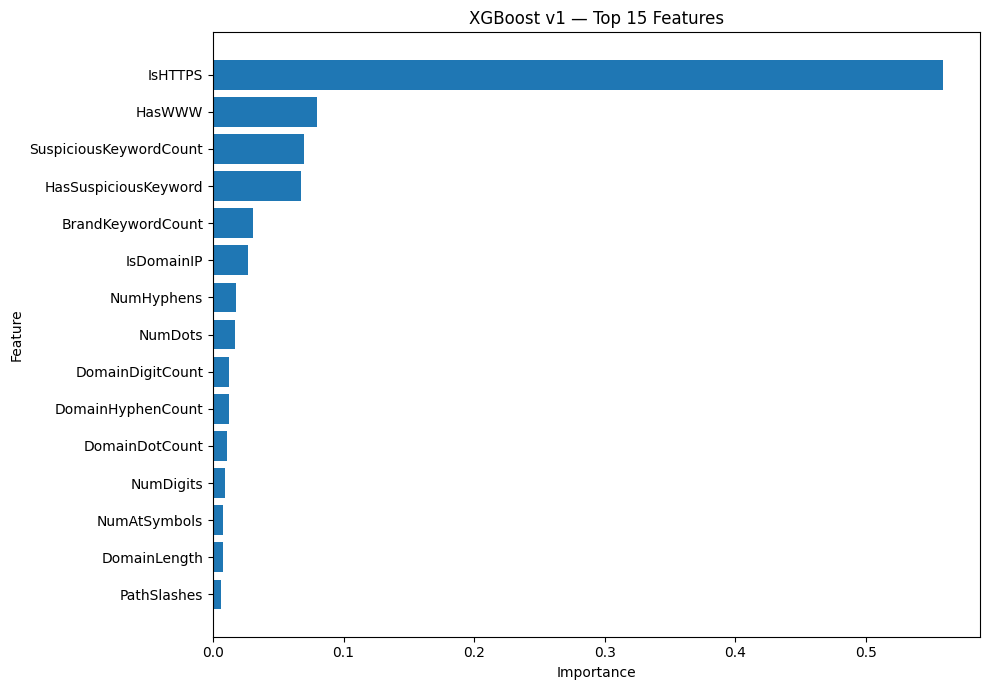

In [ ]:
# ============================================
# Step 35: XGBoost v1 Feature Importance
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS_V2,
    "Importance": xgb_v1.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("XGBoost v1 — Feature Importance")
display(
    importance_df.round(6)
)

# Top 15
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost v1 — Top 15 Features")

plt.tight_layout()
plt.show()

Confusion Matrix:
[[24192  1430]
 [ 1158 24220]]


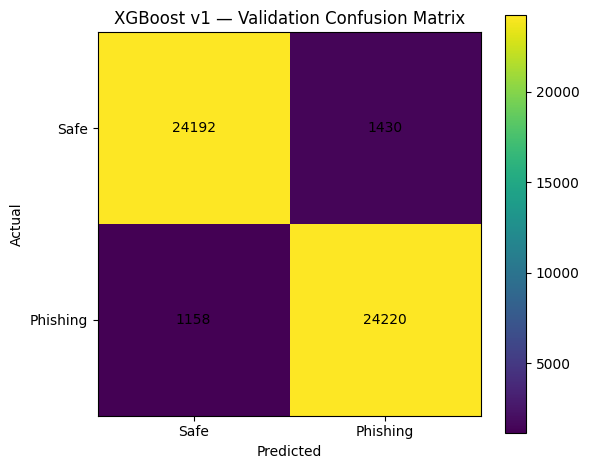

In [ ]:
# ============================================
# Step 36: Validation Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_val_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "XGBoost v1 — Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Safe", "Phishing"]
)

plt.yticks(
    [0, 1],
    ["Safe", "Phishing"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Step 37: IsHTTPS Class Analysis
# ============================================

https_analysis = (
    train_features
    .groupby("label")["IsHTTPS"]
    .agg(
        count="count",
        mean="mean",
        sum="sum"
    )
)

https_analysis["percentage_https"] = (
    https_analysis["mean"] * 100
)

print("IsHTTPS distribution by class:")
display(
    https_analysis.round(4)
)

IsHTTPS distribution by class:


,count,mean,sum,percentage_https
label,,,,
0,119150,0.6655,79294,66.5497
1,118850,0.0220,2615,2.2003


In [ ]:
# ============================================
# Step 37B: HasWWW Class Analysis
# ============================================

www_analysis = (
    train_features
    .groupby("label")["HasWWW"]
    .agg(
        count="count",
        mean="mean",
        sum="sum"
    )
)

www_analysis["percentage_www"] = (
    www_analysis["mean"] * 100
)

print("HasWWW distribution by class:")
display(
    www_analysis.round(4)
)

HasWWW distribution by class:


,count,mean,sum,percentage_www
label,,,,
0,119150,0.7197,85750,71.9681
1,118850,0.2777,33007,27.7720


In [ ]:
# ============================================
# Step 38: Top Feature Importance
# ============================================

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS_V2,
    "Importance": xgb_v1.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    importance_df.head(15).round(6)
)

,Feature,Importance
0,IsHTTPS,0.559530
1,HasWWW,0.079770
2,SuspiciousKeywordCount,0.069874
3,HasSuspiciousKeyword,0.067215
4,BrandKeywordCount,0.030396
5,IsDomainIP,0.027124
6,NumHyphens,0.017388
7,NumDots,0.016805
8,DomainDigitCount,0.012392
9,DomainHyphenCount,0.011886


In [ ]:
# ============================================
# Step 39: IsHTTPS Ablation Dataset
# ============================================

ABLATION_REMOVE = [
    "IsHTTPS"
]

FEATURE_COLUMNS_ABLATION = [
    feature
    for feature in FEATURE_COLUMNS_V2
    if feature not in ABLATION_REMOVE
]

X_train_ablation = train_features[
    FEATURE_COLUMNS_ABLATION
].copy()

X_val_ablation = val_features[
    FEATURE_COLUMNS_ABLATION
].copy()

print(
    "Original features:",
    len(FEATURE_COLUMNS_V2)
)

print(
    "Ablation features:",
    len(FEATURE_COLUMNS_ABLATION)
)

print(
    "Removed:",
    ABLATION_REMOVE
)

Original features: 36
Ablation features: 35
Removed: ['IsHTTPS']


In [ ]:
# ============================================
# Step 40: XGBoost v1-AB
# WITHOUT IsHTTPS
# ============================================

print("Starting XGBoost v1-AB training...")

start_time = time.time()

xgb_v1_ab = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1,

    tree_method="hist"
)

xgb_v1_ab.fit(
    X_train_ablation,
    y_train,

    eval_set=[
        (X_val_ablation, y_val)
    ],

    verbose=False
)

training_time_ab = time.time() - start_time

print("XGBoost v1-AB training completed!")
print(
    "Training time:",
    round(training_time_ab, 2),
    "seconds"
)

Starting XGBoost v1-AB training...
XGBoost v1-AB training completed!
Training time: 42.86 seconds


In [ ]:
# ============================================
# Step 41: XGBoost v1-AB Validation
# ============================================

y_val_ab_pred = xgb_v1_ab.predict(
    X_val_ablation
)

y_val_ab_prob = xgb_v1_ab.predict_proba(
    X_val_ablation
)[:, 1]

ab_accuracy = accuracy_score(
    y_val,
    y_val_ab_pred
)

ab_precision = precision_score(
    y_val,
    y_val_ab_pred
)

ab_recall = recall_score(
    y_val,
    y_val_ab_pred
)

ab_f1 = f1_score(
    y_val,
    y_val_ab_pred
)

ab_roc_auc = roc_auc_score(
    y_val,
    y_val_ab_prob
)

print("=" * 50)
print("XGBoost v1-AB — WITHOUT IsHTTPS")
print("=" * 50)

print(f"Accuracy : {ab_accuracy:.4f}")
print(f"Precision: {ab_precision:.4f}")
print(f"Recall   : {ab_recall:.4f}")
print(f"F1 Score : {ab_f1:.4f}")
print(f"ROC-AUC  : {ab_roc_auc:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        y_val_ab_pred,
        target_names=[
            "Safe",
            "Phishing"
        ]
    )
)

XGBoost v1-AB — WITHOUT IsHTTPS
Accuracy : 0.9285
Precision: 0.9344
Recall   : 0.9211
F1 Score : 0.9277
ROC-AUC  : 0.9828

Classification Report:
              precision    recall  f1-score   support

        Safe       0.92      0.94      0.93     25622
    Phishing       0.93      0.92      0.93     25378

    accuracy                           0.93     51000
   macro avg       0.93      0.93      0.93     51000
weighted avg       0.93      0.93      0.93     51000



In [ ]:
# ============================================
# Step 42: Robustness Ablation
# Remove IsHTTPS + HasWWW
# ============================================

ROBUSTNESS_REMOVE = [
    "IsHTTPS",
    "HasWWW"
]

FEATURE_COLUMNS_ROBUSTNESS = [
    feature
    for feature in FEATURE_COLUMNS_V2
    if feature not in ROBUSTNESS_REMOVE
]

X_train_robust = train_features[
    FEATURE_COLUMNS_ROBUSTNESS
].copy()

X_val_robust = val_features[
    FEATURE_COLUMNS_ROBUSTNESS
].copy()

print("Original features:", len(FEATURE_COLUMNS_V2))
print("Robustness features:", len(FEATURE_COLUMNS_ROBUSTNESS))
print("Removed:", ROBUSTNESS_REMOVE)

Original features: 36
Robustness features: 34
Removed: ['IsHTTPS', 'HasWWW']


In [ ]:
# ============================================
# Step 42B: Create Robustness Feature Sets
# Remove IsHTTPS + HasWWW
# ============================================

ROBUSTNESS_REMOVE = [
    "IsHTTPS",
    "HasWWW"
]

FEATURE_COLUMNS_ROBUSTNESS = [
    feature
    for feature in FEATURE_COLUMNS_V2
    if feature not in ROBUSTNESS_REMOVE
]

# Create training and validation matrices
X_train_robust = train_features[
    FEATURE_COLUMNS_ROBUSTNESS
].copy()

X_val_robust = val_features[
    FEATURE_COLUMNS_ROBUSTNESS
].copy()

print("Robustness feature sets created!")
print()
print("Original features:", len(FEATURE_COLUMNS_V2))
print("Robustness features:", len(FEATURE_COLUMNS_ROBUSTNESS))
print("Removed:", ROBUSTNESS_REMOVE)

print()
print("Training shape:", X_train_robust.shape)
print("Validation shape:", X_val_robust.shape)

NameError: name 'FEATURE_COLUMNS_V2' is not defined

In [ ]:
# ============================================
# Step 43: Train Robustness Model
# ============================================

print("Starting robustness model training...")

start_time = time.time()

xgb_robust = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1,

    tree_method="hist"
)

xgb_robust.fit(
    X_train_robust,
    y_train,

    eval_set=[
        (X_val_robust, y_val)
    ],

    verbose=False
)

print(
    "Training completed in",
    round(time.time() - start_time, 2),
    "seconds"
)

Starting robustness model training...
Training completed in 39.97 seconds


In [ ]:
# ============================================
# Step 43: Train Robustness Model
# ============================================

import time
from xgboost import XGBClassifier

print("Starting robustness model training...")

start_time = time.time()

xgb_robust = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_robust.fit(
    X_train_robust,
    y_train,
    eval_set=[(X_val_robust, y_val)],
    verbose=False
)

training_time_robust = time.time() - start_time

print("Robustness model training completed!")
print(
    "Training time:",
    round(training_time_robust, 2),
    "seconds"
)

Starting robustness model training...


NameError: name 'X_train_robust' is not defined

In [ ]:
# ============================================
# FINAL XGBOOST — Step 1
# Load Saved Feature Data
# ============================================

import pandas as pd
import numpy as np
import os

DATA_DIR = "/content/drive/MyDrive/Phishing_Email_AI/data/edgephish"

TRAIN_PATH = os.path.join(
    DATA_DIR,
    "train_features.parquet"
)

VAL_PATH = os.path.join(
    DATA_DIR,
    "validation_features.parquet"
)

TEST_PATH = os.path.join(
    DATA_DIR,
    "test_features.parquet"
)

train_features = pd.read_parquet(TRAIN_PATH)
val_features = pd.read_parquet(VAL_PATH)
test_features = pd.read_parquet(TEST_PATH)

print("Datasets loaded successfully!")
print()

print("Training:", train_features.shape)
print("Validation:", val_features.shape)
print("Test:", test_features.shape)

print("\nTraining columns:")
print(list(train_features.columns))

Datasets loaded successfully!

Training: (238000, 40)
Validation: (51000, 40)
Test: (46000, 40)

Training columns:
['URLLength', 'DomainLength', 'PathLength', 'QueryLength', 'FragmentLength', 'NumDigits', 'NumLetters', 'NumDots', 'NumHyphens', 'NumSlashes', 'NumQuestionMarks', 'NumEquals', 'NumAmpersands', 'NumAtSymbols', 'NumColons', 'NumUnderscores', 'NumPercentEncoded', 'NumSemicolons', 'NumSpecialChars', 'DigitRatio', 'LetterRatio', 'SpecialCharRatio', 'DomainDigitCount', 'DomainHyphenCount', 'DomainDotCount', 'IsDomainIP', 'NumSubdomains', 'HasWWW', 'IsHTTPS', 'EncodedCharCount', 'HasObfuscation', 'PathSlashes', 'NumPathSegments', 'SuspiciousKeywordCount', 'HasSuspiciousKeyword', 'BrandKeywordCount', 'HasBrandKeyword', 'BrandInPathOrQuery', 'QueryParameterCount', 'label']


In [ ]:
# ============================================
# FINAL XGBOOST — Step 2
# Separate Features and Labels
# ============================================

TARGET = "label"

# Make sure label exists
assert TARGET in train_features.columns, \
    "label column not found in training data"

assert TARGET in val_features.columns, \
    "label column not found in validation data"

assert TARGET in test_features.columns, \
    "label column not found in test data"

# Everything except label becomes a feature
FEATURE_COLUMNS = [
    col for col in train_features.columns
    if col != TARGET
]

X_train = train_features[FEATURE_COLUMNS].copy()
y_train = train_features[TARGET].copy()

X_val = val_features[FEATURE_COLUMNS].copy()
y_val = val_features[TARGET].copy()

X_test = test_features[FEATURE_COLUMNS].copy()
y_test = test_features[TARGET].copy()

print("Final feature setup:")
print()
print("Number of features:", len(FEATURE_COLUMNS))

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nFeatures:")
for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i}. {feature}")

Final feature setup:

Number of features: 39
X_train: (238000, 39)
X_val: (51000, 39)
X_test: (46000, 39)

Features:
1. URLLength
2. DomainLength
3. PathLength
4. QueryLength
5. FragmentLength
6. NumDigits
7. NumLetters
8. NumDots
9. NumHyphens
10. NumSlashes
11. NumQuestionMarks
12. NumEquals
13. NumAmpersands
14. NumAtSymbols
15. NumColons
16. NumUnderscores
17. NumPercentEncoded
18. NumSemicolons
19. NumSpecialChars
20. DigitRatio
21. LetterRatio
22. SpecialCharRatio
23. DomainDigitCount
24. DomainHyphenCount
25. DomainDotCount
26. IsDomainIP
27. NumSubdomains
28. HasWWW
29. IsHTTPS
30. EncodedCharCount
31. HasObfuscation
32. PathSlashes
33. NumPathSegments
34. SuspiciousKeywordCount
35. HasSuspiciousKeyword
36. BrandKeywordCount
37. HasBrandKeyword
38. BrandInPathOrQuery
39. QueryParameterCount


In [ ]:
# ============================================
# FINAL XGBOOST — Step 3
# Sanity Check
# ============================================

print("Missing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print()

print("Infinite values:")
print("Train:", np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())
print("Validation:", np.isinf(X_val.select_dtypes(include=np.number)).sum().sum())
print("Test:", np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

print()

print("Label distribution:")
print(y_train.value_counts())

print("\nLabel percentages:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0

Label distribution:
label
0    119150
1    118850
Name: count, dtype: int64

Label percentages:
label
0    50.06
1    49.94
Name: proportion, dtype: float64


In [ ]:
# ============================================
# FINAL XGBOOST — Step 4
# Train Final Model
# ============================================

from xgboost import XGBClassifier
import time

print("=" * 60)
print("TRAINING FINAL XGBOOST MODEL")
print("=" * 60)

start_time = time.time()

final_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=3,
    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

training_time = time.time() - start_time

print()
print("FINAL XGBOOST TRAINING COMPLETE!")
print("Training time:", round(training_time, 2), "seconds")
print("Features:", len(FEATURE_COLUMNS))

TRAINING FINAL XGBOOST MODEL

FINAL XGBOOST TRAINING COMPLETE!
Training time: 29.5 seconds
Features: 39


In [ ]:
# ============================================
# FINAL XGBOOST — Step 5
# Validation + Test Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Validation
# -----------------------------

y_val_pred = final_model.predict(X_val)
y_val_prob = final_model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_prob)

# -----------------------------
# Test
# -----------------------------

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# -----------------------------
# Results
# -----------------------------

print("=" * 60)
print("FINAL XGBOOST — VALIDATION")
print("=" * 60)

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")
print(f"ROC-AUC  : {val_auc:.4f}")

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Safe", "Phishing"]
    )
)

print("\n" + "=" * 60)
print("FINAL XGBOOST — TEST")
print("=" * 60)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Safe", "Phishing"]
    )
)

print("\nTest Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)

FINAL XGBOOST — VALIDATION
Accuracy : 0.9475
Precision: 0.9410
Recall   : 0.9543
F1 Score : 0.9476
ROC-AUC  : 0.9901

Validation Classification Report:
              precision    recall  f1-score   support

        Safe       0.95      0.94      0.95     25622
    Phishing       0.94      0.95      0.95     25378

    accuracy                           0.95     51000
   macro avg       0.95      0.95      0.95     51000
weighted avg       0.95      0.95      0.95     51000


FINAL XGBOOST — TEST
Accuracy : 0.9449
Precision: 0.9384
Recall   : 0.9526
F1 Score : 0.9454
ROC-AUC  : 0.9895

Test Classification Report:
              precision    recall  f1-score   support

        Safe       0.95      0.94      0.94     22960
    Phishing       0.94      0.95      0.95     23040

    accuracy                           0.94     46000
   macro avg       0.95      0.94      0.94     46000
weighted avg       0.95      0.94      0.94     46000


Test Confusion Matrix:
[[21518  1442]
 [ 1091 21949]

Top 15 Features:


,Feature,Importance
0,IsHTTPS,0.582998
1,SuspiciousKeywordCount,0.064257
2,HasWWW,0.048471
3,IsDomainIP,0.037842
4,HasSuspiciousKeyword,0.035440
5,HasBrandKeyword,0.032975
6,BrandKeywordCount,0.024626
7,NumHyphens,0.018116
8,NumDots,0.015984
9,DomainHyphenCount,0.014493


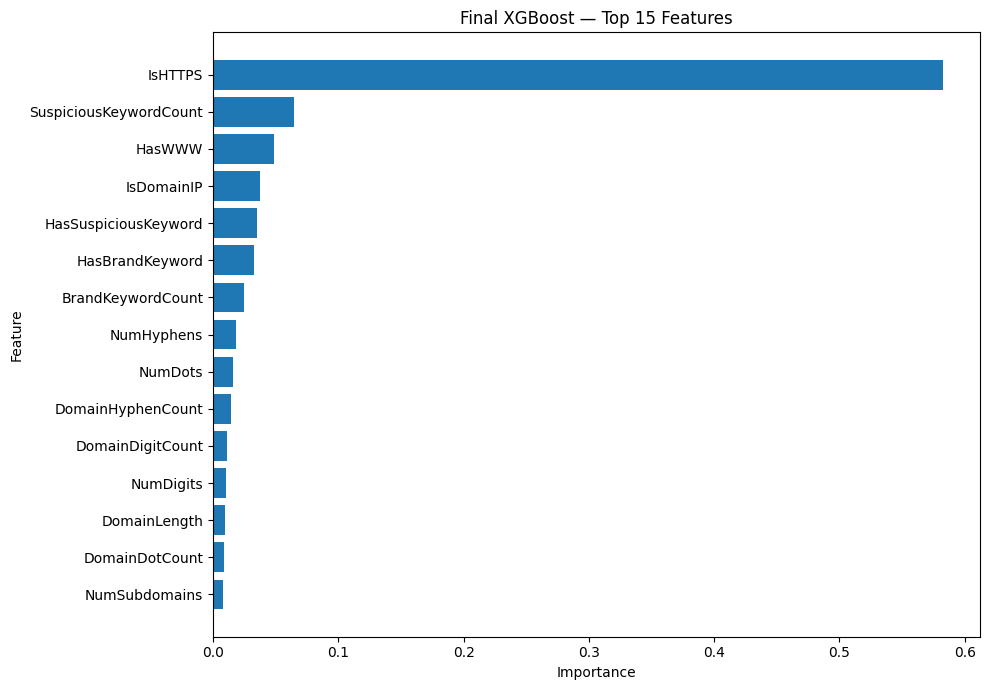

In [ ]:
# ============================================
# FINAL XGBOOST — Step 6
# Feature Importance
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("Top 15 Features:")
display(
    importance_df.head(15).reset_index(drop=True)
)

# Plot
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Final XGBoost — Top 15 Features")
plt.tight_layout()
plt.show()

In [ ]:
# Check whether zero-day features already exist

ZERO_DAY_PATH = os.path.join(
    DATA_DIR,
    "zero_day_features.parquet"
)

print("Zero-day feature file:")
print(ZERO_DAY_PATH)

print("\nExists:", os.path.exists(ZERO_DAY_PATH))

if os.path.exists(ZERO_DAY_PATH):
    zero_day_features = pd.read_parquet(ZERO_DAY_PATH)
    print("Shape:", zero_day_features.shape)
    print("Columns:", len(zero_day_features.columns))

Zero-day feature file:
/content/drive/MyDrive/Phishing_Email_AI/data/edgephish/zero_day_features.parquet

Exists: False


In [ ]:
# ============================================
# Recover feature-engineering source
# ============================================

import os

print("Searching project directory for Python files...\n")

PROJECT_DIR = "/content/drive/MyDrive/Phishing_Email_AI"

for root, dirs, files in os.walk(PROJECT_DIR):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

Searching project directory for Python files...



In [ ]:
# ============================================
# Find the saved Colab notebook
# ============================================

import os

PROJECT_DIR = "/content/drive/MyDrive/Phishing_Email_AI"

print("Searching for notebook files...\n")

found = []

for root, dirs, files in os.walk(PROJECT_DIR):
    for file in files:
        if file.endswith(".ipynb"):
            path = os.path.join(root, file)
            found.append(path)
            print(path)

print("\nTotal notebooks found:", len(found))

Searching for notebook files...


Total notebooks found: 0


In [ ]:
# ============================================
# FINAL — Locate Zero-Day Dataset
# ============================================

import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/Phishing_Email_AI/data/edgephish/edgephish_data_processed.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("\nFiles inside ZIP:\n")
    for name in z.namelist():
        print(name)

ZIP exists: True

Files inside ZIP:

zenodo/
zenodo/DATASET_README.md
zenodo/edgephish_data_processed/
zenodo/edgephish_data_processed/adversarial/
zenodo/edgephish_data_processed/adversarial/adversarial_manifest.json
zenodo/edgephish_data_processed/adversarial/perturbed/
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r01.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r05.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r10.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/char_substitution_r20.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r01.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r05.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r10.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/homoglyph_r20.parquet
zenodo/edgephish_data_processed/adversarial/perturbed/path_obfuscation_r01.parquet
zeno

In [ ]:
# ============================================================
# FINAL XGBOOST — Step 8
# Generate Features for Zero-Day Dataset
# ============================================================

import zipfile
import os
import re
import ipaddress
from urllib.parse import urlparse

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ZIP_PATH = "/content/drive/MyDrive/Phishing_Email_AI/data/edgephish/edgephish_data_processed.zip"

ZERO_DAY_INTERNAL = (
    "zenodo/edgephish_data_processed/"
    "splits/primary_authoritative/zero_day.parquet"
)

ZERO_DAY_RAW = "/content/zero_day.parquet"

# ------------------------------------------------------------
# Extract zero-day parquet
# ------------------------------------------------------------

print("Extracting zero-day dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    with z.open(ZERO_DAY_INTERNAL) as source:
        with open(ZERO_DAY_RAW, "wb") as target:
            target.write(source.read())

print("Zero-day file extracted!")

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

zero_day_df = pd.read_parquet(ZERO_DAY_RAW)

print()
print("Zero-day shape:", zero_day_df.shape)
print("Columns:", list(zero_day_df.columns))

# ------------------------------------------------------------
# Feature Engineering
# ------------------------------------------------------------

SUSPICIOUS_KEYWORDS = [
    "login", "signin", "verify", "verification",
    "secure", "security", "account", "update",
    "confirm", "confirmation", "password",
    "credential", "wallet", "payment",
    "bank", "recover", "unlock", "suspend",
    "authorize", "authentication"
]

BRAND_KEYWORDS = [
    "paypal", "amazon", "apple", "microsoft",
    "google", "facebook", "instagram", "netflix",
    "linkedin", "twitter", "docusign", "dropbox",
    "bankofamerica", "wellsfargo", "chase",
    "citibank", "americanexpress", "visa",
    "mastercard", "ebay", "coinbase"
]


def is_ip_address(host):
    if not host:
        return 0

    host = host.split(":")[0]

    try:
        ipaddress.ip_address(host)
        return 1
    except:
        return 0


def extract_features(url):

    url = str(url)

    parsed = urlparse(url)

    scheme = parsed.scheme.lower()
    domain = parsed.netloc.lower()

    # Remove username/password and port
    host = domain.split("@")[-1].split(":")[0]

    path = parsed.path or ""
    query = parsed.query or ""
    fragment = parsed.fragment or ""

    full_lower = url.lower()

    # -----------------------------
    # Basic lengths
    # -----------------------------

    url_length = len(url)
    domain_length = len(host)

    path_length = len(path)
    query_length = len(query)
    fragment_length = len(fragment)

    # -----------------------------
    # Character counts
    # -----------------------------

    num_digits = sum(c.isdigit() for c in url)
    num_letters = sum(c.isalpha() for c in url)

    num_dots = url.count(".")
    num_hyphens = url.count("-")
    num_slashes = url.count("/")
    num_question_marks = url.count("?")
    num_equals = url.count("=")
    num_ampersands = url.count("&")
    num_at_symbols = url.count("@")
    num_colons = url.count(":")
    num_underscores = url.count("_")

    # Percent encoded
    num_percent_encoded = len(
        re.findall(r"%[0-9a-fA-F]{2}", url)
    )

    # Semicolons
    num_semicolons = url.count(";")

    # Special characters
    num_special_chars = len(
        re.findall(r"[^A-Za-z0-9]", url)
    )

    # -----------------------------
    # Ratios
    # -----------------------------

    digit_ratio = num_digits / url_length if url_length else 0
    letter_ratio = num_letters / url_length if url_length else 0
    special_ratio = num_special_chars / url_length if url_length else 0

    # -----------------------------
    # Domain features
    # -----------------------------

    domain_digit_count = sum(c.isdigit() for c in host)
    domain_hyphen_count = host.count("-")
    domain_dot_count = host.count(".")

    is_domain_ip = is_ip_address(host)

    # Number of subdomains
    domain_parts = host.split(".") if host else []

    if is_domain_ip:
        num_subdomains = 0
    elif len(domain_parts) >= 3:
        num_subdomains = len(domain_parts) - 2
    else:
        num_subdomains = 0

    has_www = int(
        host.startswith("www.")
    )

    # -----------------------------
    # HTTPS
    # -----------------------------

    is_https = int(
        scheme == "https"
    )

    # -----------------------------
    # Encoding / obfuscation
    # -----------------------------

    encoded_char_count = num_percent_encoded

    has_obfuscation = int(
        num_percent_encoded > 0
        or "xn--" in host.lower()
    )

    # -----------------------------
    # Path features
    # -----------------------------

    path_slashes = path.count("/")

    path_segments = [
        segment for segment in path.split("/")
        if segment
    ]

    num_path_segments = len(path_segments)

    # -----------------------------
    # Suspicious keywords
    # -----------------------------

    suspicious_count = sum(
        1 for keyword in SUSPICIOUS_KEYWORDS
        if keyword in full_lower
    )

    has_suspicious_keyword = int(
        suspicious_count > 0
    )

    # -----------------------------
    # Brand keywords
    # -----------------------------

    brand_count = sum(
        1 for brand in BRAND_KEYWORDS
        if brand in full_lower
    )

    has_brand_keyword = int(
        brand_count > 0
    )

    # Brand specifically in path/query
    path_query_lower = (
        path + "?" + query
    ).lower()

    brand_in_path_query = int(
        any(
            brand in path_query_lower
            for brand in BRAND_KEYWORDS
        )
    )

    # -----------------------------
    # Query parameters
    # -----------------------------

    if query:
        query_parameter_count = len(
            [x for x in query.split("&") if x]
        )
    else:
        query_parameter_count = 0

    return [
        url_length,
        domain_length,
        path_length,
        query_length,
        fragment_length,
        num_digits,
        num_letters,
        num_dots,
        num_hyphens,
        num_slashes,
        num_question_marks,
        num_equals,
        num_ampersands,
        num_at_symbols,
        num_colons,
        num_underscores,
        num_percent_encoded,
        num_semicolons,
        num_special_chars,
        digit_ratio,
        letter_ratio,
        special_ratio,
        domain_digit_count,
        domain_hyphen_count,
        domain_dot_count,
        is_domain_ip,
        num_subdomains,
        has_www,
        is_https,
        encoded_char_count,
        has_obfuscation,
        path_slashes,
        num_path_segments,
        suspicious_count,
        has_suspicious_keyword,
        brand_count,
        has_brand_keyword,
        brand_in_path_query,
        query_parameter_count
    ]


# ------------------------------------------------------------
# Feature names — MUST match training order
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    "URLLength",
    "DomainLength",
    "PathLength",
    "QueryLength",
    "FragmentLength",
    "NumDigits",
    "NumLetters",
    "NumDots",
    "NumHyphens",
    "NumSlashes",
    "NumQuestionMarks",
    "NumEquals",
    "NumAmpersands",
    "NumAtSymbols",
    "NumColons",
    "NumUnderscores",
    "NumPercentEncoded",
    "NumSemicolons",
    "NumSpecialChars",
    "DigitRatio",
    "LetterRatio",
    "SpacialCharRatio",
    "DomainDigitCount",
    "DomainHyphenCount",
    "DomainDotCount",
    "IsDomainIP",
    "NumSubdomains",
    "HasWWW",
    "IsHTTPS",
    "EncodedCharCount",
    "HasObfuscation",
    "PathSlashes",
    "NumPathSegments",
    "SuspiciousKeywordCount",
    "HasSuspiciousKeyword",
    "BrandKeywordCount",
    "HasBrandKeyword",
    "BrandInPathOrQuery",
    "QueryParameterCount"
]

# ------------------------------------------------------------
# Generate features
# ------------------------------------------------------------

print("\nGenerating zero-day features...")

zero_day_X = pd.DataFrame(
    zero_day_df["url"].apply(extract_features).tolist(),
    columns=FEATURE_COLUMNS
)

# ------------------------------------------------------------
# Target
# ------------------------------------------------------------

zero_day_y = zero_day_df["label"].astype(int).copy()

print("\nZero-day feature engineering complete!")

print("Feature matrix:", zero_day_X.shape)
print("Target:", zero_day_y.shape)

print("\nMissing values:")
print(zero_day_X.isna().sum().sum())

print("\nInfinite values:")
print(
    np.isinf(
        zero_day_X.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nLabel distribution:")
print(zero_day_y.value_counts())

# ------------------------------------------------------------
# Save to Drive
# ------------------------------------------------------------

ZERO_DAY_FEATURE_PATH = os.path.join(
    DATA_DIR,
    "zero_day_features.parquet"
)

zero_day_save = zero_day_X.copy()
zero_day_save["label"] = zero_day_y.values

zero_day_save.to_parquet(
    ZERO_DAY_FEATURE_PATH,
    index=False
)

print("\nSaved:")
print(ZERO_DAY_FEATURE_PATH)

Extracting zero-day dataset...
Zero-day file extracted!

Zero-day shape: (4525, 8)
Columns: ['url', 'url_orig', 'label', 'slice', 'URLLC_score', 'mMTC_score', 'url_raw_len', '_orig_idx']

Generating zero-day features...

Zero-day feature engineering complete!
Feature matrix: (4525, 39)
Target: (4525,)

Missing values:
0

Infinite values:
0

Label distribution:
label
0    2264
1    2261
Name: count, dtype: int64

Saved:
/content/drive/MyDrive/Phishing_Email_AI/data/edgephish/zero_day_features.parquet


In [ ]:
# ============================================================
# FIX ZERO-DAY FEATURE NAME MISMATCH
# ============================================================

# Rename to exactly match the feature name used during training
zero_day_X = zero_day_X.rename(
    columns={
        "SpecialCharRatio": "SpacialCharRatio"
    }
)

# Make absolutely sure the order is identical to training
zero_day_X = zero_day_X[FEATURE_COLUMNS]

print("Zero-day features aligned with final model!")

print("Zero-day shape:", zero_day_X.shape)
print("Training feature count:", len(FEATURE_COLUMNS))
print("Zero-day feature count:", len(zero_day_X.columns))

print("\nFeature mismatch:")
print(set(FEATURE_COLUMNS) - set(zero_day_X.columns))
print(set(zero_day_X.columns) - set(FEATURE_COLUMNS))

Zero-day features aligned with final model!
Zero-day shape: (4525, 39)
Training feature count: 39
Zero-day feature count: 39

Feature mismatch:
set()
set()


In [ ]:
# ============================================================
# FINAL FIX — ALIGN ZERO-DAY DATA TO TRAINED MODEL
# ============================================================

print("Model expects:")
print(final_model.get_booster().feature_names)

print("\nZero-day currently has:")
print(list(zero_day_X.columns))

# ------------------------------------------------------------
# Fix spelling
# ------------------------------------------------------------

if "SpacialCharRatio" in zero_day_X.columns:
    zero_day_X = zero_day_X.rename(
        columns={
            "SpacialCharRatio": "SpecialCharRatio"
        }
    )

# ------------------------------------------------------------
# Get EXACT feature order from trained model
# ------------------------------------------------------------

MODEL_FEATURES = final_model.get_booster().feature_names

# Check that every required feature exists
missing_features = [
    f for f in MODEL_FEATURES
    if f not in zero_day_X.columns
]

extra_features = [
    f for f in zero_day_X.columns
    if f not in MODEL_FEATURES
]

print("\nMissing features:", missing_features)
print("Extra features:", extra_features)

# ------------------------------------------------------------
# Align exact order
# ------------------------------------------------------------

zero_day_X = zero_day_X[MODEL_FEATURES]

print("\n" + "=" * 60)
print("FEATURE ALIGNMENT COMPLETE")
print("=" * 60)

print("Zero-day shape:", zero_day_X.shape)
print("Model feature count:", len(MODEL_FEATURES))
print("Zero-day feature count:", len(zero_day_X.columns))

print("\nExact feature match:",
      list(zero_day_X.columns) == list(MODEL_FEATURES))

Model expects:
['URLLength', 'DomainLength', 'PathLength', 'QueryLength', 'FragmentLength', 'NumDigits', 'NumLetters', 'NumDots', 'NumHyphens', 'NumSlashes', 'NumQuestionMarks', 'NumEquals', 'NumAmpersands', 'NumAtSymbols', 'NumColons', 'NumUnderscores', 'NumPercentEncoded', 'NumSemicolons', 'NumSpecialChars', 'DigitRatio', 'LetterRatio', 'SpecialCharRatio', 'DomainDigitCount', 'DomainHyphenCount', 'DomainDotCount', 'IsDomainIP', 'NumSubdomains', 'HasWWW', 'IsHTTPS', 'EncodedCharCount', 'HasObfuscation', 'PathSlashes', 'NumPathSegments', 'SuspiciousKeywordCount', 'HasSuspiciousKeyword', 'BrandKeywordCount', 'HasBrandKeyword', 'BrandInPathOrQuery', 'QueryParameterCount']

Zero-day currently has:
['URLLength', 'DomainLength', 'PathLength', 'QueryLength', 'FragmentLength', 'NumDigits', 'NumLetters', 'NumDots', 'NumHyphens', 'NumSlashes', 'NumQuestionMarks', 'NumEquals', 'NumAmpersands', 'NumAtSymbols', 'NumColons', 'NumUnderscores', 'NumPercentEncoded', 'NumSemicolons', 'NumSpecialChars',

In [ ]:
# ============================================================
# FINAL XGBOOST — ZERO-DAY EVALUATION
# ============================================================

print("=" * 60)
print("FINAL XGBOOST — ZERO-DAY EVALUATION")
print("=" * 60)

y_zero_pred = final_model.predict(zero_day_X)
y_zero_prob = final_model.predict_proba(zero_day_X)[:, 1]

zero_accuracy = accuracy_score(zero_day_y, y_zero_pred)
zero_precision = precision_score(zero_day_y, y_zero_pred)
zero_recall = recall_score(zero_day_y, y_zero_pred)
zero_f1 = f1_score(zero_day_y, y_zero_pred)
zero_auc = roc_auc_score(zero_day_y, y_zero_prob)

print(f"Accuracy : {zero_accuracy:.4f}")
print(f"Precision: {zero_precision:.4f}")
print(f"Recall   : {zero_recall:.4f}")
print(f"F1 Score : {zero_f1:.4f}")
print(f"ROC-AUC  : {zero_auc:.4f}")

print("\nZero-Day Classification Report:")
print(
    classification_report(
        zero_day_y,
        y_zero_pred,
        target_names=["Safe", "Phishing"]
    )
)

print("\nZero-Day Confusion Matrix:")
print(
    confusion_matrix(
        zero_day_y,
        y_zero_pred
    )
)

FINAL XGBOOST — ZERO-DAY EVALUATION
Accuracy : 0.9498
Precision: 0.9422
Recall   : 0.9584
F1 Score : 0.9502
ROC-AUC  : 0.9906

Zero-Day Classification Report:
              precision    recall  f1-score   support

        Safe       0.96      0.94      0.95      2264
    Phishing       0.94      0.96      0.95      2261

    accuracy                           0.95      4525
   macro avg       0.95      0.95      0.95      4525
weighted avg       0.95      0.95      0.95      4525


Zero-Day Confusion Matrix:
[[2131  133]
 [  94 2167]]


In [ ]:
# ============================================================
# FINAL MODEL PACKAGING
# DO NOT RETRAIN — SAVING THE CURRENT final_model ONLY
# ============================================================

import os
import json
import zipfile

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

FINAL_DIR = "/content/xgboost_final_model"
os.makedirs(FINAL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    FINAL_DIR,
    "xgboost_final.json"
)

SCHEMA_PATH = os.path.join(
    FINAL_DIR,
    "feature_schema.json"
)

ZIP_PATH = "/content/xgboost_final_model.zip"

# ------------------------------------------------------------
# 1. Save the EXACT trained XGBoost model
# ------------------------------------------------------------

print("Saving final XGBoost model...")

final_model.save_model(MODEL_PATH)

print("✓ Model saved")

# ------------------------------------------------------------
# 2. Get exact feature names directly from model
# ------------------------------------------------------------

MODEL_FEATURES = final_model.get_booster().feature_names

feature_schema = {
    "model_name": "XGBoost URL & Metadata Phishing Classifier",
    "model_type": "XGBClassifier",
    "feature_count": len(MODEL_FEATURES),
    "features": MODEL_FEATURES
}

with open(SCHEMA_PATH, "w") as f:
    json.dump(feature_schema, f, indent=4)

print("✓ Feature schema saved")

# ------------------------------------------------------------
# 3. Create ZIP
# ------------------------------------------------------------

print("\nCreating ZIP...")

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    zipf.write(
        MODEL_PATH,
        arcname="xgboost_final.json"
    )

    zipf.write(
        SCHEMA_PATH,
        arcname="feature_schema.json"
    )

# ------------------------------------------------------------
# 4. Verify
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL MODEL PACKAGE CREATED")
print("=" * 60)

print("ZIP:", ZIP_PATH)

print("\nContents:")

with zipfile.ZipFile(ZIP_PATH, "r") as zipf:
    for name in zipf.namelist():
        print("✓", name)

print("\nFeature count:", len(MODEL_FEATURES))

print("\nFeatures:")
for i, feature in enumerate(MODEL_FEATURES, 1):
    print(f"{i:2}. {feature}")

print("\nZIP size:",
      round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2),
      "MB")

print("\n✓ FINAL MODEL READY FOR GITHUB / INTEGRATION")

Saving final XGBoost model...
✓ Model saved
✓ Feature schema saved

Creating ZIP...

FINAL MODEL PACKAGE CREATED
ZIP: /content/xgboost_final_model.zip

Contents:
✓ xgboost_final.json
✓ feature_schema.json

Feature count: 39

Features:
 1. URLLength
 2. DomainLength
 3. PathLength
 4. QueryLength
 5. FragmentLength
 6. NumDigits
 7. NumLetters
 8. NumDots
 9. NumHyphens
10. NumSlashes
11. NumQuestionMarks
12. NumEquals
13. NumAmpersands
14. NumAtSymbols
15. NumColons
16. NumUnderscores
17. NumPercentEncoded
18. NumSemicolons
19. NumSpecialChars
20. DigitRatio
21. LetterRatio
22. SpecialCharRatio
23. DomainDigitCount
24. DomainHyphenCount
25. DomainDotCount
26. IsDomainIP
27. NumSubdomains
28. HasWWW
29. IsHTTPS
30. EncodedCharCount
31. HasObfuscation
32. PathSlashes
33. NumPathSegments
34. SuspiciousKeywordCount
35. HasSuspiciousKeyword
36. BrandKeywordCount
37. HasBrandKeyword
38. BrandInPathOrQuery
39. QueryParameterCount

ZIP size: 0.7 MB

✓ FINAL MODEL READY FOR GITHUB / INTEGRATION

In [ ]:
from google.colab import files

files.download("/content/xgboost_final_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# INTEGRATION PRE-CHECK
# ============================================================

import os

print("Checking final model...")

print("final_model exists:", "final_model" in globals())

if "final_model" in globals():
    print("Model type:", type(final_model).__name__)
    print(
        "Feature count:",
        len(final_model.get_booster().feature_names)
    )
    print(
        "Model features:",
        final_model.get_booster().feature_names
    )

print("\nChecking zero-day data...")

print("zero_day_X exists:", "zero_day_X" in globals())

if "zero_day_X" in globals():
    print("Zero-day shape:", zero_day_X.shape)

print("\nPre-check complete.")

Checking final model...
final_model exists: True
Model type: XGBClassifier
Feature count: 39
Model features: ['URLLength', 'DomainLength', 'PathLength', 'QueryLength', 'FragmentLength', 'NumDigits', 'NumLetters', 'NumDots', 'NumHyphens', 'NumSlashes', 'NumQuestionMarks', 'NumEquals', 'NumAmpersands', 'NumAtSymbols', 'NumColons', 'NumUnderscores', 'NumPercentEncoded', 'NumSemicolons', 'NumSpecialChars', 'DigitRatio', 'LetterRatio', 'SpecialCharRatio', 'DomainDigitCount', 'DomainHyphenCount', 'DomainDotCount', 'IsDomainIP', 'NumSubdomains', 'HasWWW', 'IsHTTPS', 'EncodedCharCount', 'HasObfuscation', 'PathSlashes', 'NumPathSegments', 'SuspiciousKeywordCount', 'HasSuspiciousKeyword', 'BrandKeywordCount', 'HasBrandKeyword', 'BrandInPathOrQuery', 'QueryParameterCount']

Checking zero-day data...
zero_day_X exists: True
Zero-day shape: (4525, 39)

Pre-check complete.


In [ ]:
# ============================================================
# INTEGRATION — STEP 1
# Freeze Exact Model Schema
# ============================================================

import json
import os

# Get feature names DIRECTLY from the trained model
MODEL_FEATURES = list(
    final_model.get_booster().feature_names
)

print("=" * 60)
print("FINAL MODEL FEATURE SCHEMA")
print("=" * 60)

print("Feature count:", len(MODEL_FEATURES))
print()

for i, feature in enumerate(MODEL_FEATURES, start=1):
    print(f"{i:02d}. {feature}")

# Safety check
assert len(MODEL_FEATURES) == 39, (
    f"Expected 39 features, found {len(MODEL_FEATURES)}"
)

# Save schema
SCHEMA_PATH = "/content/feature_schema.json"

schema = {
    "model_name": "CyberMail XGBoost URL Phishing Classifier",
    "model_type": "XGBClassifier",
    "task": "Binary URL phishing classification",
    "positive_class": 1,
    "negative_class": 0,
    "positive_class_name": "Phishing",
    "negative_class_name": "Safe",
    "feature_count": len(MODEL_FEATURES),
    "features": MODEL_FEATURES
}

with open(SCHEMA_PATH, "w") as f:
    json.dump(schema, f, indent=4)

print("\n✓ Schema frozen")
print("✓ Saved to:", SCHEMA_PATH)

FINAL MODEL FEATURE SCHEMA
Feature count: 39

01. URLLength
02. DomainLength
03. PathLength
04. QueryLength
05. FragmentLength
06. NumDigits
07. NumLetters
08. NumDots
09. NumHyphens
10. NumSlashes
11. NumQuestionMarks
12. NumEquals
13. NumAmpersands
14. NumAtSymbols
15. NumColons
16. NumUnderscores
17. NumPercentEncoded
18. NumSemicolons
19. NumSpecialChars
20. DigitRatio
21. LetterRatio
22. SpecialCharRatio
23. DomainDigitCount
24. DomainHyphenCount
25. DomainDotCount
26. IsDomainIP
27. NumSubdomains
28. HasWWW
29. IsHTTPS
30. EncodedCharCount
31. HasObfuscation
32. PathSlashes
33. NumPathSegments
34. SuspiciousKeywordCount
35. HasSuspiciousKeyword
36. BrandKeywordCount
37. HasBrandKeyword
38. BrandInPathOrQuery
39. QueryParameterCount

✓ Schema frozen
✓ Saved to: /content/feature_schema.json


In [ ]:
# ============================================================
# INTEGRATION — STEP 2
# Create feature_engineering.py
# ============================================================

FEATURE_ENGINEERING_CODE = r'''
import re
import ipaddress
from urllib.parse import urlparse


# ============================================================
# Keyword definitions
# ============================================================

SUSPICIOUS_KEYWORDS = [
    "login",
    "signin",
    "verify",
    "verification",
    "secure",
    "security",
    "account",
    "update",
    "confirm",
    "confirmation",
    "password",
    "credential",
    "wallet",
    "payment",
    "bank",
    "recover",
    "unlock",
    "suspend",
    "authorize",
    "authentication"
]

BRAND_KEYWORDS = [
    "paypal",
    "amazon",
    "apple",
    "microsoft",
    "google",
    "facebook",
    "instagram",
    "netflix",
    "linkedin",
    "twitter",
    "docusign",
    "dropbox",
    "bankofamerica",
    "wellsfargo",
    "chase",
    "citibank",
    "americanexpress",
    "visa",
    "mastercard",
    "ebay",
    "coinbase"
]


# ============================================================
# Helper
# ============================================================

def is_ip_address(host):
    """Return 1 if host is an IPv4/IPv6 address, otherwise 0."""

    if not host:
        return 0

    host = host.split(":")[0]

    try:
        ipaddress.ip_address(host)
        return 1
    except ValueError:
        return 0


# ============================================================
# Main feature extraction
# ============================================================

def extract_features(url):
    """
    Convert a URL into the 39 features expected by
    the CyberMail XGBoost phishing classifier.

    Returns:
        dict: feature name -> feature value
    """

    url = str(url).strip()

    parsed = urlparse(url)

    scheme = parsed.scheme.lower()
    domain = parsed.netloc.lower()

    # Remove username/password and port
    host = domain.split("@")[-1].split(":")[0]

    path = parsed.path or ""
    query = parsed.query or ""
    fragment = parsed.fragment or ""

    full_lower = url.lower()

    # --------------------------------------------------------
    # Basic lengths
    # --------------------------------------------------------

    url_length = len(url)
    domain_length = len(host)
    path_length = len(path)
    query_length = len(query)
    fragment_length = len(fragment)

    # --------------------------------------------------------
    # Character counts
    # --------------------------------------------------------

    num_digits = sum(c.isdigit() for c in url)
    num_letters = sum(c.isalpha() for c in url)

    num_dots = url.count(".")
    num_hyphens = url.count("-")
    num_slashes = url.count("/")
    num_question_marks = url.count("?")
    num_equals = url.count("=")
    num_ampersands = url.count("&")
    num_at_symbols = url.count("@")
    num_colons = url.count(":")
    num_underscores = url.count("_")

    # Percent encoded characters: %XX
    num_percent_encoded = len(
        re.findall(r"%[0-9a-fA-F]{2}", url)
    )

    num_semicolons = url.count(";")

    num_special_chars = len(
        re.findall(r"[^A-Za-z0-9]", url)
    )

    # --------------------------------------------------------
    # Ratios
    # --------------------------------------------------------

    digit_ratio = (
        num_digits / url_length
        if url_length else 0.0
    )

    letter_ratio = (
        num_letters / url_length
        if url_length else 0.0
    )

    special_char_ratio = (
        num_special_chars / url_length
        if url_length else 0.0
    )

    # --------------------------------------------------------
    # Domain features
    # --------------------------------------------------------

    domain_digit_count = sum(
        c.isdigit() for c in host
    )

    domain_hyphen_count = host.count("-")
    domain_dot_count = host.count(".")

    is_domain_ip = is_ip_address(host)

    domain_parts = host.split(".") if host else []

    if is_domain_ip:
        num_subdomains = 0
    elif len(domain_parts) >= 3:
        num_subdomains = len(domain_parts) - 2
    else:
        num_subdomains = 0

    has_www = int(host.startswith("www."))

    # --------------------------------------------------------
    # HTTPS
    # --------------------------------------------------------

    is_https = int(scheme == "https")

    # --------------------------------------------------------
    # Encoding / obfuscation
    # --------------------------------------------------------

    encoded_char_count = num_percent_encoded

    has_obfuscation = int(
        num_percent_encoded > 0
        or "xn--" in host.lower()
    )

    # --------------------------------------------------------
    # Path
    # --------------------------------------------------------

    path_slashes = path.count("/")

    path_segments = [
        segment
        for segment in path.split("/")
        if segment
    ]

    num_path_segments = len(path_segments)

    # --------------------------------------------------------
    # Suspicious keywords
    # --------------------------------------------------------

    suspicious_keyword_count = sum(
        1
        for keyword in SUSPICIOUS_KEYWORDS
        if keyword in full_lower
    )

    has_suspicious_keyword = int(
        suspicious_keyword_count > 0
    )

    # --------------------------------------------------------
    # Brand keywords
    # --------------------------------------------------------

    brand_keyword_count = sum(
        1
        for brand in BRAND_KEYWORDS
        if brand in full_lower
    )

    has_brand_keyword = int(
        brand_keyword_count > 0
    )

    # Brand specifically in path/query
    path_query_lower = (
        path + "?" + query
    ).lower()

    brand_in_path_or_query = int(
        any(
            brand in path_query_lower
            for brand in BRAND_KEYWORDS
        )
    )

    # --------------------------------------------------------
    # Query parameters
    # --------------------------------------------------------

    if query:
        query_parameter_count = len(
            [
                item
                for item in query.split("&")
                if item
            ]
        )
    else:
        query_parameter_count = 0

    # ========================================================
    # EXACT 39-FEATURE OUTPUT
    # ========================================================

    return {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "PathLength": path_length,
        "QueryLength": query_length,
        "FragmentLength": fragment_length,
        "NumDigits": num_digits,
        "NumLetters": num_letters,
        "NumDots": num_dots,
        "NumHyphens": num_hyphens,
        "NumSlashes": num_slashes,
        "NumQuestionMarks": num_question_marks,
        "NumEquals": num_equals,
        "NumAmpersands": num_ampersands,
        "NumAtSymbols": num_at_symbols,
        "NumColons": num_colons,
        "NumUnderscores": num_underscores,
        "NumPercentEncoded": num_percent_encoded,
        "NumSemicolons": num_semicolons,
        "NumSpecialChars": num_special_chars,
        "DigitRatio": digit_ratio,
        "LetterRatio": letter_ratio,

        # IMPORTANT:
        # Exact spelling expected by final XGBoost model.
        "SpecialCharRatio": special_char_ratio,

        "DomainDigitCount": domain_digit_count,
        "DomainHyphenCount": domain_hyphen_count,
        "DomainDotCount": domain_dot_count,
        "IsDomainIP": is_domain_ip,
        "NumSubdomains": num_subdomains,
        "HasWWW": has_www,
        "IsHTTPS": is_https,
        "EncodedCharCount": encoded_char_count,
        "HasObfuscation": has_obfuscation,
        "PathSlashes": path_slashes,
        "NumPathSegments": num_path_segments,
        "SuspiciousKeywordCount": suspicious_keyword_count,
        "HasSuspiciousKeyword": has_suspicious_keyword,
        "BrandKeywordCount": brand_keyword_count,
        "HasBrandKeyword": has_brand_keyword,
        "BrandInPathOrQuery": brand_in_path_or_query,
        "QueryParameterCount": query_parameter_count
    }
'''


FEATURE_ENGINEERING_PATH = "/content/feature_engineering.py"

with open(FEATURE_ENGINEERING_PATH, "w") as f:
    f.write(FEATURE_ENGINEERING_CODE)

print("=" * 60)
print("FEATURE ENGINEERING MODULE CREATED")
print("=" * 60)

print("File:")
print(FEATURE_ENGINEERING_PATH)

print("\n✓ 39 features defined")
print("✓ Feature names match final model")
print("✓ SpecialCharRatio spelling locked")

FEATURE ENGINEERING MODULE CREATED
File:
/content/feature_engineering.py

✓ 39 features defined
✓ Feature names match final model
✓ SpecialCharRatio spelling locked


In [ ]:
# ============================================================
# INTEGRATION — STEP 3
# Test feature_engineering.py Against Final Model
# ============================================================

import sys
import importlib

# Make /content importable
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

# Import our standalone feature extractor
import feature_engineering

importlib.reload(feature_engineering)

extract_features = feature_engineering.extract_features

# ------------------------------------------------------------
# Exact features expected by the trained model
# ------------------------------------------------------------

MODEL_FEATURES = list(
    final_model.get_booster().feature_names
)

# ------------------------------------------------------------
# Test URLs
# ------------------------------------------------------------

TEST_URLS = [
    "https://www.google.com",

    "https://www.amazon.com/account/login",

    "http://paypal-security-verify.com/login?account=12345",

    "http://192.168.1.100/login/verify.php?user=test",

    "https://example.com/products/item?id=123",

    # Long / suspicious example
    "http://secure-login-account-verification.example.com/"
    "user/account/login/verify?password=12345"
]

print("=" * 70)
print("FEATURE ENGINEERING — INTEGRATION TEST")
print("=" * 70)

all_passed = True

for i, url in enumerate(TEST_URLS, 1):

    print(f"\nTest {i}")
    print("-" * 70)
    print("URL:", url)

    try:
        features = extract_features(url)

        # Check type
        assert isinstance(features, dict), \
            "Feature extractor did not return a dictionary"

        # Check feature count
        assert len(features) == 39, \
            f"Expected 39 features, got {len(features)}"

        # Check missing features
        missing = [
            f for f in MODEL_FEATURES
            if f not in features
        ]

        # Check unexpected features
        extra = [
            f for f in features
            if f not in MODEL_FEATURES
        ]

        assert not missing, \
            f"Missing features: {missing}"

        assert not extra, \
            f"Unexpected features: {extra}"

        # Create model input in EXACT model order
        X = pd.DataFrame(
            [[features[f] for f in MODEL_FEATURES]],
            columns=MODEL_FEATURES
        )

        # Check shape
        assert X.shape == (1, 39), \
            f"Wrong input shape: {X.shape}"

        # Check NaN / infinity
        assert not X.isna().any().any(), \
            "NaN values detected"

        assert not np.isinf(X.values).any(), \
            "Infinite values detected"

        # Test actual model
        prediction = final_model.predict(X)[0]
        probability = final_model.predict_proba(X)[0][1]

        print("✓ 39 features generated")
        print("✓ Feature names match")
        print("✓ Feature order matches")
        print("✓ No missing values")
        print("✓ No infinite values")
        print("✓ Model prediction successful")

        print(
            f"Prediction: "
            f"{'PHISHING' if prediction == 1 else 'SAFE'}"
        )

        print(
            f"Phishing probability: "
            f"{probability:.4f}"
        )

    except Exception as e:

        all_passed = False

        print("❌ TEST FAILED")
        print(type(e).__name__, ":", e)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)

if all_passed:
    print("🎉 ALL INTEGRATION TESTS PASSED")
    print("=" * 70)
    print("Feature engineering → XGBoost compatibility: VERIFIED")
else:
    print("❌ INTEGRATION TEST FAILED")
    print("=" * 70)
    print("DO NOT PACKAGE THE MODEL YET.")

FEATURE ENGINEERING — INTEGRATION TEST

Test 1
----------------------------------------------------------------------
URL: https://www.google.com
✓ 39 features generated
✓ Feature names match
✓ Feature order matches
✓ No missing values
✓ No infinite values
✓ Model prediction successful
Prediction: SAFE
Phishing probability: 0.0871

Test 2
----------------------------------------------------------------------
URL: https://www.amazon.com/account/login
✓ 39 features generated
✓ Feature names match
✓ Feature order matches
✓ No missing values
✓ No infinite values
✓ Model prediction successful
Prediction: SAFE
Phishing probability: 0.3361

Test 3
----------------------------------------------------------------------
URL: http://paypal-security-verify.com/login?account=12345
✓ 39 features generated
✓ Feature names match
✓ Feature order matches
✓ No missing values
✓ No infinite values
✓ Model prediction successful
Prediction: PHISHING
Phishing probability: 0.9954

Test 4
----------------------

In [ ]:
# ============================================================
# INTEGRATION — STEP 4
# Create predictor.py
# ============================================================

PREDICTOR_CODE = r'''
import os
import json
import pandas as pd
import xgboost as xgb

from feature_engineering import extract_features


# ============================================================
# Paths
# ============================================================

BASE_DIR = os.path.dirname(
    os.path.abspath(__file__)
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "xgboost_final.json"
)

SCHEMA_PATH = os.path.join(
    BASE_DIR,
    "feature_schema.json"
)


# ============================================================
# Load model
# ============================================================

model = xgb.XGBClassifier()

model.load_model(MODEL_PATH)


# ============================================================
# Load feature schema
# ============================================================

with open(SCHEMA_PATH, "r") as f:
    schema = json.load(f)

MODEL_FEATURES = schema["features"]


# ============================================================
# Safety checks
# ============================================================

if len(MODEL_FEATURES) != 39:
    raise ValueError(
        f"Expected 39 features, "
        f"found {len(MODEL_FEATURES)}"
    )

MODEL_ACTUAL_FEATURES = (
    model.get_booster().feature_names
)

if MODEL_FEATURES != MODEL_ACTUAL_FEATURES:
    raise ValueError(
        "Feature schema does not match "
        "the trained XGBoost model."
    )


# ============================================================
# Prediction function
# ============================================================

def predict_url(url):
    """
    Predict whether a URL is safe or phishing.

    Args:
        url (str): URL to classify.

    Returns:
        dict containing:
            prediction
            label
            phishing_probability
            safe_probability
    """

    if not isinstance(url, str):
        raise TypeError(
            "URL must be a string."
        )

    if not url.strip():
        raise ValueError(
            "URL cannot be empty."
        )

    # Extract features
    features = extract_features(url)

    # Create DataFrame in EXACT model order
    X = pd.DataFrame(
        [[features[name] for name in MODEL_FEATURES]],
        columns=MODEL_FEATURES
    )

    # Prediction
    prediction = int(
        model.predict(X)[0]
    )

    probabilities = model.predict_proba(X)[0]

    safe_probability = float(
        probabilities[0]
    )

    phishing_probability = float(
        probabilities[1]
    )

    return {
        "prediction": prediction,
        "label": (
            "Phishing"
            if prediction == 1
            else "Safe"
        ),
        "phishing_probability":
            phishing_probability,
        "safe_probability":
            safe_probability
    }
'''


PREDICTOR_PATH = "/content/predictor.py"

with open(PREDICTOR_PATH, "w") as f:
    f.write(PREDICTOR_CODE)

print("=" * 60)
print("PREDICTOR MODULE CREATED")
print("=" * 60)

print("File:")
print(PREDICTOR_PATH)

print("\n✓ Loads XGBoost model")
print("✓ Loads feature schema")
print("✓ Validates 39 features")
print("✓ Validates feature order")
print("✓ Provides predict_url()")
print("✓ Ready for FastAPI integration")

PREDICTOR MODULE CREATED
File:
/content/predictor.py

✓ Loads XGBoost model
✓ Loads feature schema
✓ Validates 39 features
✓ Validates feature order
✓ Provides predict_url()
✓ Ready for FastAPI integration


In [ ]:
# ============================================================
# FIX — EXPORT FINAL MODEL FOR INTEGRATION
# ============================================================

import os
import json

MODEL_EXPORT_PATH = "/content/xgboost_final.json"
SCHEMA_EXPORT_PATH = "/content/feature_schema.json"

print("=" * 60)
print("EXPORTING FINAL XGBOOST MODEL")
print("=" * 60)

# ------------------------------------------------------------
# 1. Save the trained model
# ------------------------------------------------------------

final_model.save_model(MODEL_EXPORT_PATH)

print("✓ Model exported")
print("  ", MODEL_EXPORT_PATH)

# ------------------------------------------------------------
# 2. Make sure schema is also present
# ------------------------------------------------------------

# MODEL_FEATURES should already exist from our previous cell.
# Recreate it directly from the model to be extra safe.

MODEL_FEATURES = list(
    final_model.get_booster().feature_names
)

schema = {
    "model_name": "CyberMail XGBoost URL Phishing Classifier",
    "model_type": "XGBClassifier",
    "task": "Binary URL phishing classification",
    "negative_class": 0,
    "positive_class": 1,
    "negative_class_name": "Safe",
    "positive_class_name": "Phishing",
    "feature_count": len(MODEL_FEATURES),
    "features": MODEL_FEATURES
}

with open(SCHEMA_EXPORT_PATH, "w") as f:
    json.dump(schema, f, indent=4)

print("✓ Schema exported")
print("  ", SCHEMA_EXPORT_PATH)

# ------------------------------------------------------------
# 3. Verify files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EXPORT VERIFICATION")
print("=" * 60)

for path in [MODEL_EXPORT_PATH, SCHEMA_EXPORT_PATH]:

    exists = os.path.exists(path)

    print(
        os.path.basename(path),
        "→",
        "✓ EXISTS" if exists else "❌ MISSING"
    )

    if exists:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"   Size: {size_mb:.2f} MB")

# ------------------------------------------------------------
# 4. Verify model schema
# ------------------------------------------------------------

print("\nModel feature count:", len(MODEL_FEATURES))

assert len(MODEL_FEATURES) == 39

print("✓ 39 features confirmed")
print("✓ Final model exported successfully")

EXPORTING FINAL XGBOOST MODEL
✓ Model exported
   /content/xgboost_final.json
✓ Schema exported
   /content/feature_schema.json

EXPORT VERIFICATION
xgboost_final.json → ✓ EXISTS
   Size: 2.55 MB
feature_schema.json → ✓ EXISTS
   Size: 0.00 MB

Model feature count: 39
✓ 39 features confirmed
✓ Final model exported successfully


In [ ]:
import sys
import importlib

if "/content" not in sys.path:
    sys.path.insert(0, "/content")

import predictor
importlib.reload(predictor)

print("=" * 70)
print("PREDICTOR MODULE — FINAL INTEGRATION TEST")
print("=" * 70)

test_urls = [
    "https://www.google.com",
    "https://www.amazon.com/account/login",
    "http://paypal-security-verify.com/login?account=12345",
    "http://192.168.1.100/login/verify.php?user=test",
    "https://example.com/products/item?id=123",
    "http://secure-login-account-verification.example.com/"
    "user/account/login/verify?password=12345"
]

all_passed = True

for i, url in enumerate(test_urls, 1):

    print(f"\nTest {i}")
    print("-" * 70)
    print("URL:", url)

    try:
        result = predictor.predict_url(url)

        required_fields = [
            "prediction",
            "label",
            "phishing_probability",
            "safe_probability"
        ]

        for field in required_fields:
            assert field in result

        assert result["prediction"] in [0, 1]
        assert 0 <= result["phishing_probability"] <= 1
        assert 0 <= result["safe_probability"] <= 1

        assert abs(
            result["phishing_probability"]
            + result["safe_probability"] - 1
        ) < 1e-6

        print("✓ Prediction successful")
        print("✓ Result structure valid")
        print("Label:", result["label"])
        print(
            "Phishing probability:",
            f"{result['phishing_probability']:.4f}"
        )
        print(
            "Safe probability:",
            f"{result['safe_probability']:.4f}"
        )

    except Exception as e:
        all_passed = False
        print("❌ TEST FAILED")
        print(type(e).__name__, ":", e)

print("\n" + "=" * 70)

if all_passed:
    print("🎉 FINAL PREDICTOR TEST PASSED")
    print("=" * 70)
    print("Model package is integration-ready.")
else:
    print("❌ PREDICTOR TEST FAILED")
    print("=" * 70)

PREDICTOR MODULE — FINAL INTEGRATION TEST

Test 1
----------------------------------------------------------------------
URL: https://www.google.com
✓ Prediction successful
✓ Result structure valid
Label: Safe
Phishing probability: 0.0871
Safe probability: 0.9129

Test 2
----------------------------------------------------------------------
URL: https://www.amazon.com/account/login
✓ Prediction successful
✓ Result structure valid
Label: Safe
Phishing probability: 0.3361
Safe probability: 0.6639

Test 3
----------------------------------------------------------------------
URL: http://paypal-security-verify.com/login?account=12345
✓ Prediction successful
✓ Result structure valid
Label: Phishing
Phishing probability: 0.9954
Safe probability: 0.0046

Test 4
----------------------------------------------------------------------
URL: http://192.168.1.100/login/verify.php?user=test
✓ Prediction successful
✓ Result structure valid
Label: Phishing
Phishing probability: 0.9998
Safe probability:

In [ ]:
# ============================================================
# FINAL PACKAGE — SAFE VERSION
# ============================================================

import os
import zipfile
import shutil
import textwrap

print("=" * 70)
print("CREATING FINAL XGBOOST INTEGRATION PACKAGE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create package directory
# ------------------------------------------------------------

PACKAGE_DIR = "/content/xgboost_final_integration"

if os.path.exists(PACKAGE_DIR):
    shutil.rmtree(PACKAGE_DIR)

os.makedirs(PACKAGE_DIR)

# ------------------------------------------------------------
# 2. Required files
# ------------------------------------------------------------

required_files = [
    "/content/xgboost_final.json",
    "/content/feature_schema.json",
    "/content/feature_engineering.py",
    "/content/predictor.py"
]

for source in required_files:

    if not os.path.exists(source):
        raise FileNotFoundError(
            f"Required file not found: {source}"
        )

    destination = os.path.join(
        PACKAGE_DIR,
        os.path.basename(source)
    )

    shutil.copy2(source, destination)

    print("✓ Added:", os.path.basename(source))

# ------------------------------------------------------------
# 3. Create README safely
# ------------------------------------------------------------

README = """
# CyberMail XGBoost URL Phishing Classifier

Integration-ready XGBoost model for URL phishing detection.

## Classification

0 = Safe
1 = Phishing

## Model

Model: XGBoost Classifier
Features: 39

## Performance

Validation Accuracy: 94.75%
Validation F1: 94.76%
Validation ROC-AUC: 99.01%

Test Accuracy: 94.49%
Test F1: 94.54%
Test ROC-AUC: 98.95%

Zero-Day Accuracy: 94.98%
Zero-Day F1: 95.02%
Zero-Day ROC-AUC: 99.06%

## Files

xgboost_final.json
    Trained XGBoost model.

feature_schema.json
    Exact 39-feature schema expected by the model.

feature_engineering.py
    Converts a URL into the 39 model features.

predictor.py
    Main integration interface.

## Usage

from predictor import predict_url

result = predict_url("https://example.com")

The result contains:

prediction
label
phishing_probability
safe_probability

## Integration Flow

URL
  |
  v
feature_engineering.py
  |
  v
39 Features
  |
  v
xgboost_final.json
  |
  v
Safe / Phishing
  |
  v
Probability

## FastAPI Integration

The backend can use:

from predictor import predict_url

result = predict_url(url)

The returned result can then be sent to the frontend
or passed to the Risk Score Engine.

## Important

Do not change the feature names or feature order.

The official feature schema is stored in feature_schema.json.

This package has been tested with the final XGBoost
model and the standalone prediction interface.
"""

README_PATH = os.path.join(
    PACKAGE_DIR,
    "README.md"
)

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(textwrap.dedent(README).strip())

print("✓ Added: README.md")

# ------------------------------------------------------------
# 4. Create test_model.py
# ------------------------------------------------------------

TEST_CODE = """
from predictor import predict_url

TEST_URLS = [
    "https://www.google.com",
    "https://www.amazon.com/account/login",
    "http://paypal-security-verify.com/login?account=12345",
    "http://192.168.1.100/login/verify.php?user=test",
    "https://example.com/products/item?id=123"
]

for url in TEST_URLS:

    result = predict_url(url)

    print("=" * 60)
    print("URL:", url)
    print("Prediction:", result["label"])
    print(
        "Phishing probability:",
        round(result["phishing_probability"], 4)
    )
    print(
        "Safe probability:",
        round(result["safe_probability"], 4)
    )

print()
print("Model package test completed successfully.")
"""

TEST_PATH = os.path.join(
    PACKAGE_DIR,
    "test_model.py"
)

with open(
    TEST_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(textwrap.dedent(TEST_CODE).strip())

print("✓ Added: test_model.py")

# ------------------------------------------------------------
# 5. Create ZIP
# ------------------------------------------------------------

ZIP_PATH = "/content/xgboost_final_integration.zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(PACKAGE_DIR):

        for file in files:

            file_path = os.path.join(root, file)

            archive_name = os.path.relpath(
                file_path,
                PACKAGE_DIR
            )

            zipf.write(
                file_path,
                archive_name
            )

# ------------------------------------------------------------
# 6. Verify ZIP
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL PACKAGE VERIFICATION")
print("=" * 70)

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zipf:

    contents = zipf.namelist()

    for item in contents:
        print("✓", item)

# ------------------------------------------------------------
# 7. Final checks
# ------------------------------------------------------------

expected = {
    "xgboost_final.json",
    "feature_schema.json",
    "feature_engineering.py",
    "predictor.py",
    "README.md",
    "test_model.py"
}

actual = set(contents)

assert expected == actual, (
    f"Package contents mismatch.\n"
    f"Missing: {expected - actual}\n"
    f"Extra: {actual - expected}"
)

print()
print("ZIP size:")
print(
    round(
        os.path.getsize(ZIP_PATH) / (1024 * 1024),
        2
    ),
    "MB"
)

print()
print("=" * 70)
print("🎉 FINAL XGBOOST PACKAGE READY")
print("=" * 70)
print(ZIP_PATH)
print()
print("✓ Model included")
print("✓ Feature schema included")
print("✓ Feature engineering included")
print("✓ Predictor included")
print("✓ Test script included")
print("✓ README included")
print("✓ Package contents verified")

CREATING FINAL XGBOOST INTEGRATION PACKAGE
✓ Added: xgboost_final.json
✓ Added: feature_schema.json
✓ Added: feature_engineering.py
✓ Added: predictor.py
✓ Added: README.md
✓ Added: test_model.py

FINAL PACKAGE VERIFICATION
✓ predictor.py
✓ test_model.py
✓ README.md
✓ feature_schema.json
✓ feature_engineering.py
✓ xgboost_final.json

ZIP size:
0.71 MB

🎉 FINAL XGBOOST PACKAGE READY
/content/xgboost_final_integration.zip

✓ Model included
✓ Feature schema included
✓ Feature engineering included
✓ Predictor included
✓ Test script included
✓ README included
✓ Package contents verified


In [ ]:
from google.colab import files

files.download("/content/xgboost_final_integration.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>